In [29]:
import sys
import pandas as pd
pd.set_option('display.max_rows', 200)  # 设置显示的最大行数为 200
pd.set_option('display.max_columns', 50)  # 设置显示的最大列数为 50
variables = locals().copy()
for var_name, var_value in variables.items():
    if(var_name!='merged_table' or var_name!='first_table_merge'):
        del var_name
import gc
pd.options.mode.chained_assignment = None  # 不推荐，但有时必要
gc.collect()
import os
from tqdm import tqdm
import datetime

### Loading data

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime, timedelta

import rqdatac
rqdatac.init()
rqdatac.user.get_quota()

In [ ]:
date = '2022-03-31'
univers = rqdatac.index_components('000300.XSHG',start_date = date,end_date =date)[datetime(2022, 3, 31)]

In [ ]:
dates = [
    "2022-01-04", "2022-01-05", "2022-01-06", "2022-01-07", 
    "2022-01-10", "2022-01-11", "2022-01-12", "2022-01-13", "2022-01-14", 
    "2022-01-17", "2022-01-18", "2022-01-19", "2022-01-20", "2022-01-21", 
    "2022-01-24", "2022-01-25", "2022-01-26", "2022-01-27", "2022-01-28", 
    "2022-02-07", "2022-02-08", "2022-02-09", "2022-02-10", "2022-02-11", 
    "2022-02-14", "2022-02-15", "2022-02-16", "2022-02-17", "2022-02-18", 
    "2022-02-21", "2022-02-22", "2022-02-23", "2022-02-24", "2022-02-25", 
    "2022-02-28"
]
for date in tqdm(dates[1:]):
    os.makedirs(f'./tickdata/{date}/', exist_ok=True)
    for univ in univers[:20]:
        intra = rqdatac.get_price(univ, start_date=date, end_date=date, frequency='tick',expect_df=True)
        intra.to_parquet(f'./tickdata/{date}/{univ}.pq')
    

In [ ]:
dates = [
    "2022-01-04", "2022-01-05", "2022-01-06", "2022-01-07", 
    "2022-01-10", "2022-01-11", "2022-01-12", "2022-01-13", "2022-01-14", 
    "2022-01-17", "2022-01-18", "2022-01-19", "2022-01-20", "2022-01-21", 
    "2022-01-24", "2022-01-25", "2022-01-26", "2022-01-27", "2022-01-28", 
    "2022-02-07", "2022-02-08", "2022-02-09", "2022-02-10", "2022-02-11", 
    "2022-02-14", "2022-02-15", "2022-02-16", "2022-02-17", "2022-02-18", 
    "2022-02-21", "2022-02-22", "2022-02-23", "2022-02-24", "2022-02-25", 
    "2022-02-28"
]
for date in tqdm(dates):
    os.makedirs(f'./tickdata2/{date}/', exist_ok=True)
    for univ in univers[:20]:
        intra = pd.read_parquet(f'./tickdata/{date}/{univ}.pq')
        intra.reset_index('order_book_id', inplace=True)
        intra['ret1h_shift'] = intra['last'].pct_change(freq='-60 min').shift(-1)
        intra['ret30min_shift'] = intra['last'].pct_change(freq='-30 min').shift(-1)
        intra['ret0e_shift'] = intra['last'].iloc[-1] / intra['last'] - 1.
        intra['date'] = intra.index.get_level_values('datetime').date
        intra['time'] = intra.index.get_level_values('datetime').time
        intra.to_parquet(f'./tickdata2/{date}/{univ}.pq')

### Imb react

In [45]:
univers = ['000001.XSHE', '000002.XSHE', '000063.XSHE', '000066.XSHE', '000069.XSHE', '000100.XSHE', '000157.XSHE', '000166.XSHE', '000301.XSHE', '000333.XSHE', '000338.XSHE', '000425.XSHE', '000538.XSHE', '000568.XSHE', '000596.XSHE', '000625.XSHE', '000651.XSHE', '000661.XSHE', '000703.XSHE', '000708.XSHE', '000725.XSHE', '000768.XSHE', '000776.XSHE', '000783.XSHE', '000786.XSHE', '000800.XSHE', '000858.XSHE', '000876.XSHE', '000895.XSHE', '000938.XSHE', '000963.XSHE', '000977.XSHE', '001979.XSHE', '002001.XSHE', '002007.XSHE', '002008.XSHE', '002024.XSHE', '002027.XSHE', '002032.XSHE', '002044.XSHE', '002049.XSHE', '002050.XSHE', '002064.XSHE', '002120.XSHE', '002129.XSHE', '002142.XSHE', '002157.XSHE', '002179.XSHE', '002202.XSHE', '002230.XSHE', '002236.XSHE', '002241.XSHE', '002252.XSHE', '002271.XSHE', '002304.XSHE', '002311.XSHE', '002352.XSHE', '002371.XSHE', '002410.XSHE', '002414.XSHE', '002415.XSHE', '002459.XSHE', '002460.XSHE', '002466.XSHE', '002475.XSHE', '002493.XSHE', '002555.XSHE', '002568.XSHE', '002594.XSHE', '002600.XSHE', '002601.XSHE', '002602.XSHE', '002607.XSHE', '002624.XSHE', '002709.XSHE', '002714.XSHE', '002736.XSHE', '002791.XSHE', '002812.XSHE', '002821.XSHE', '002841.XSHE', '002916.XSHE', '002938.XSHE', '003816.XSHE', '300003.XSHE', '300014.XSHE', '300015.XSHE', '300033.XSHE', '300059.XSHE', '300122.XSHE', '300124.XSHE', '300142.XSHE', '300144.XSHE', '300274.XSHE', '300316.XSHE', '300347.XSHE', '300408.XSHE', '300413.XSHE', '300433.XSHE', '300450.XSHE', '300498.XSHE', '300529.XSHE', '300558.XSHE', '300595.XSHE', '300601.XSHE', '300628.XSHE', '300676.XSHE', '300677.XSHE', '300750.XSHE', '300759.XSHE', '300760.XSHE', '300782.XSHE', '300866.XSHE', '300888.XSHE', '300896.XSHE', '300999.XSHE', '600000.XSHG', '600009.XSHG', '600010.XSHG', '600011.XSHG', '600015.XSHG', '600016.XSHG', '600018.XSHG', '600019.XSHG', '600025.XSHG', '600028.XSHG', '600029.XSHG', '600030.XSHG', '600031.XSHG', '600036.XSHG', '600048.XSHG', '600050.XSHG', '600061.XSHG', '600079.XSHG', '600085.XSHG', '600104.XSHG', '600109.XSHG', '600111.XSHG', '600115.XSHG', '600132.XSHG', '600143.XSHG', '600150.XSHG', '600161.XSHG', '600176.XSHG', '600183.XSHG', '600196.XSHG', '600276.XSHG', '600309.XSHG', '600332.XSHG', '600346.XSHG', '600352.XSHG', '600362.XSHG', '600383.XSHG', '600406.XSHG', '600426.XSHG', '600436.XSHG', '600438.XSHG', '600489.XSHG', '600519.XSHG', '600547.XSHG', '600570.XSHG', '600584.XSHG', '600585.XSHG', '600588.XSHG', '600600.XSHG', '600606.XSHG', '600655.XSHG', '600660.XSHG', '600690.XSHG', '600741.XSHG', '600745.XSHG', '600760.XSHG', '600763.XSHG', '600795.XSHG', '600809.XSHG', '600837.XSHG', '600845.XSHG', '600848.XSHG', '600872.XSHG', '600886.XSHG', '600887.XSHG', '600893.XSHG', '600900.XSHG', '600905.XSHG', '600918.XSHG', '600919.XSHG', '600926.XSHG', '600958.XSHG', '600989.XSHG', '600999.XSHG', '601006.XSHG', '601009.XSHG', '601012.XSHG', '601021.XSHG', '601066.XSHG', '601088.XSHG', '601100.XSHG', '601108.XSHG', '601111.XSHG', '601138.XSHG', '601155.XSHG', '601162.XSHG', '601166.XSHG', '601169.XSHG', '601186.XSHG', '601211.XSHG', '601216.XSHG', '601225.XSHG', '601229.XSHG', '601231.XSHG', '601236.XSHG', '601238.XSHG', '601288.XSHG', '601318.XSHG', '601319.XSHG', '601328.XSHG', '601336.XSHG', '601360.XSHG', '601377.XSHG', '601390.XSHG', '601398.XSHG', '601600.XSHG', '601601.XSHG', '601607.XSHG', '601618.XSHG', '601628.XSHG', '601633.XSHG', '601658.XSHG', '601668.XSHG', '601669.XSHG', '601688.XSHG', '601696.XSHG', '601698.XSHG', '601728.XSHG', '601766.XSHG', '601788.XSHG', '601799.XSHG', '601800.XSHG', '601808.XSHG', '601816.XSHG', '601818.XSHG', '601838.XSHG', '601857.XSHG', '601865.XSHG', '601868.XSHG', '601877.XSHG', '601878.XSHG', '601881.XSHG', '601888.XSHG', '601898.XSHG', '601899.XSHG', '601901.XSHG', '601916.XSHG', '601919.XSHG', '601933.XSHG', '601939.XSHG', '601966.XSHG', '601985.XSHG', '601988.XSHG', '601989.XSHG', '601990.XSHG', '601995.XSHG', '601998.XSHG', '603019.XSHG', '603087.XSHG', '603160.XSHG', '603195.XSHG', '603233.XSHG', '603259.XSHG', '603260.XSHG', '603288.XSHG', '603338.XSHG', '603369.XSHG', '603392.XSHG', '603486.XSHG', '603501.XSHG', '603517.XSHG', '603658.XSHG', '603659.XSHG', '603799.XSHG', '603806.XSHG', '603833.XSHG', '603882.XSHG', '603899.XSHG', '603939.XSHG', '603986.XSHG', '603993.XSHG', '605499.XSHG', '688008.XSHG', '688009.XSHG', '688012.XSHG', '688036.XSHG', '688111.XSHG', '688126.XSHG', '688169.XSHG', '688363.XSHG', '688396.XSHG', '688561.XSHG', '688599.XSHG', '688981.XSHG']
dates = [
    "2022-01-04", "2022-01-05", "2022-01-06", "2022-01-07", 
    "2022-01-10", "2022-01-11", "2022-01-12", "2022-01-13", "2022-01-14", 
    "2022-01-17", "2022-01-18", "2022-01-19", "2022-01-20", "2022-01-21", 
    "2022-01-24", "2022-01-25", "2022-01-26", "2022-01-27", "2022-01-28", 
    "2022-02-07", "2022-02-08", "2022-02-09", "2022-02-10", "2022-02-11", 
    "2022-02-14", "2022-02-15", "2022-02-16", "2022-02-17", "2022-02-18", 
    "2022-02-21", "2022-02-22", "2022-02-23", "2022-02-24", "2022-02-25", 
    "2022-02-28"
]
results = []
for univ in tqdm(univers[:20]):
    for date in (dates):
        df = pd.read_parquet(f'./tickdata2/{date}/{univ}.pq')
        results.append(df[(df.index.time>datetime.time(9, 30)) & (df.index.time<datetime.time(14, 57))].reset_index())
intra = pd.concat(results)

intra.set_index('datetime', inplace=True)
del results
gc.collect()

intra['single_vol'] = intra.groupby(['date','order_book_id'])['volume'].diff()
intra['single_turnover'] = intra.groupby(['date','order_book_id'])['total_turnover'].diff()
intra['single_numtrade'] = intra.groupby(['date','order_book_id'])['num_trades'].diff()

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.17it/s]


In [46]:
import pandas as pd
import numpy as np

def compute_imbreact(df):
    # 计算imb
    df['imb'] = (df['b1_v'] - df['a1_v']) / (df['b1_v'] + df['a1_v'])

    # 计算5avgimb（5档）
    b_cols = [f'b{i}_v' for i in range(1, 6)]
    a_cols = [f'a{i}_v' for i in range(1, 6)]
    df['wavgimb'] = (df[b_cols].sum(axis=1) - df[a_cols].sum(axis=1)) / \
                    (df[b_cols].sum(axis=1) + df[a_cols].sum(axis=1)).replace(0, np.nan)

    # 计算pxwavgimb（5档）
    b_cols = [f'b{i}_v' for i in range(1, 6)]
    a_cols = [f'a{i}_v' for i in range(1, 6)]
    bpx_cols = [f'b{i}' for i in range(1, 6)]
    apx_cols = [f'a{i}' for i in range(1, 6)]
    df['mid'] = df.eval('(a1 + b1) / 2')
    for l in range(1, 6):
        df[f'ap{l}_gap'] = df.eval(f'1/(a{l} - mid)').abs()
        df[f'bp{l}_gap'] = df.eval(f'1/(b{l} - mid)').abs()
        df[f'a{l}_vpgap'] = df[f'a{l}_v'].mul(df[f'ap{l}_gap'], axis=0)
        df[f'b{l}_vpgap'] = df[f'b{l}_v'].mul(df[f'bp{l}_gap'], axis=0)
    df['PWavg_a5'] = df[[f'a{l}_vpgap' for l in range(1, 6)]].sum(axis=1) / df[[f'ap{l}_gap' for l in range(1, 6)]].sum(axis=1)
    df['PWavg_b5'] = df[[f'b{l}_vpgap' for l in range(1, 6)]].sum(axis=1) / df[[f'bp{l}_gap' for l in range(1, 6)]].sum(axis=1)    
    df['Wavgimb'] = df.eval('(PWavg_a5 - PWavg_b5)/(PWavg_a5 + PWavg_b5)')

    df['1min_pct'] = df['last'].pct_change(freq='1min')
    df['1min_pct_abs'] = df['1min_pct'].abs()


    # 构造5min切片
    df['5min_end'] = df.index.ceil('5min') 
    result_list = []


    df['price_direction'] = np.where(
        df['1min_pct'] > 0, 'up', 
        np.where(df['1min_pct'] < 0, 'down', 'flat')
    )

    for end_time in tqdm(df['5min_end'].unique()):
        current_5min_data = df[df['5min_end'] == end_time]
        # 1. 按价格分位
        price_30pct = current_5min_data['last'].quantile(0.3)
        price_70pct = current_5min_data['last'].quantile(0.7)

        # 计算1min_pct的30%和70%分位数
        pct_30pct = current_5min_data['1min_pct'].quantile(0.3)
        pct_70pct = current_5min_data['1min_pct'].quantile(0.7)
        
        
        # 0. pct方向与imb方向同向的区段的imb
        same_dirimb_data = current_5min_data[current_5min_data['1min_pct'] * current_5min_data['imb']>0]
        same_dirimb_data_imb_mean  = same_dirimb_data['imb'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_wimb_mean = same_dirimb_data['wavgimb'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_Wimb_mean = same_dirimb_data['Wavgimb'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_numtrade_mean = same_dirimb_data['num_trade'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_singlevol_mean = same_dirimb_data['single_vol'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_singleturnover_mean = same_dirimb_data['single_turnover'].mean() if not same_dirimb_data.empty else np.nan

        
        # 0_1. pct方向与imb方向同向的区段的wimb
        same_dirwavgimb_data = current_5min_data[current_5min_data['1min_pct'] * current_5min_data['imb']>0]
        same_dirimb_data_imb_mean  = same_dirimb_data['imb'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_wimb_mean = same_dirimb_data['wavgimb'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_Wimb_mean = same_dirimb_data['Wavgimb'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_numtrade_mean = same_dirimb_data['num_trade'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_singlevol_mean = same_dirimb_data['single_vol'].mean() if not same_dirimb_data.empty else np.nan
        same_dirimb_data_singleturnover_mean = same_dirimb_data['single_turnover'].mean() if not same_dirimb_data.empty else np.nan

        # 1. 价格>70分位数的imb和wavgimb
        high_price_data = current_5min_data[current_5min_data['last'] > price_70pct]
        high_price_imb_mean = high_price_data['imb'].mean() if not high_price_data.empty else np.nan
        high_price_wavgimb_mean = high_price_data['wavgimb'].mean() if not high_price_data.empty else np.nan
        high_price_Wavgimb_mean = high_price_data['Wavgimb'].mean() if not high_price_data.empty else np.nan
        high_price_singlenumtrade_mean = high_price_data['single_num_trade'].mean() if not high_price_data.empty else np.nan
        high_price_singlevol_mean = high_price_data['single_vol'].mean() if not high_price_data.empty else np.nan
        high_price_singleturnover_mean = high_price_data['single_turnover'].mean() if not high_price_data.empty else np.nan

        # 2. 价格<30分位数的imb和wavgimb
        low_price_data = current_5min_data[current_5min_data['last'] < price_30pct]
        low_price_imb_mean = low_price_data['imb'].mean() if not low_price_data.empty else np.nan
        low_price_wavgimb_mean = low_price_data['wavgimb'].mean() if not low_price_data.empty else np.nan
        low_price_Wavgimb_mean = low_price_data['Wavgimb'].mean() if not low_price_data.empty else np.nan
        low_price_singlenumtrade_mean = low_price_data['single_num_trade'].mean() if not low_price_data.empty else np.nan
        low_price_singlevol_mean = low_price_data['single_vol'].mean() if not low_price_data.empty else np.nan
        low_price_singleturnover_mean = low_price_data['single_turnover'].mean() if not low_price_data.empty else np.nan

        # 3. 过去1分钟价格上涨的tick的imb和wavgimb
        rising_ticks = current_5min_data[current_5min_data['price_direction'] == 'up']
        rising_imb_mean = rising_ticks['imb'].mean() if not rising_ticks.empty else np.nan
        rising_wavgimb_mean = rising_ticks['wavgimb'].mean() if not rising_ticks.empty else np.nan
        rising_Wavgimb_mean = rising_ticks['Wavgimb'].mean() if not rising_ticks.empty else np.nan
        rising_singlenumtrade_mean = rising_ticks['single_num_trade'].mean() if not rising_ticks.empty else np.nan
        rising_singlevol_mean = rising_ticks['single_vol'].mean() if not rising_ticks.empty else np.nan
        rising_singleturnover_mean = rising_ticks['single_turnover'].mean() if not rising_ticks.empty else np.nan

        # 4. 过去1分钟价格下跌的tick的imb和wavgimb
        falling_ticks = current_5min_data[current_5min_data['price_direction'] == 'down']
        falling_imb_mean = falling_ticks['imb'].mean() if not falling_ticks.empty else np.nan
        falling_wavgimb_mean = falling_ticks['wavgimb'].mean() if not falling_ticks.empty else np.nan
        falling_Wavgimb_mean = falling_ticks['Wavgimb'].mean() if not falling_ticks.empty else np.nan
        falling_singlenumtrade_mean = falling_ticks['single_num_trade'].mean() if not falling_ticks.empty else np.nan
        falling_singlevol_mean = falling_ticks['single_vol'].mean() if not falling_ticks.empty else np.nan
        falling_singleturnover_mean = falling_ticks['single_turnover'].mean() if not falling_ticks.empty else np.nan

        # 5. 1min_pct >70分位数的imb和wavgimb
        high_pct_data = current_5min_data[current_5min_data['1min_pct'] > pct_70pct]
        high_pct_imb_mean = high_pct_data['imb'].mean() if not high_pct_data.empty else np.nan
        high_pct_wavgimb_mean = high_pct_data['wavgimb'].mean() if not high_pct_data.empty else np.nan
        high_pct_Wavgimb_mean = high_pct_data['Wavgimb'].mean() if not high_pct_data.empty else np.nan
        high_pct_singlenumtrade_mean = high_pct_data['single_num_trade'].mean() if not high_pct_data.empty else np.nan
        high_pct_singlevol_mean = high_pct_data['single_vol'].mean() if not high_pct_data.empty else np.nan
        high_pct_singleturnover_mean = high_pct_data['single_turnover'].mean() if not high_pct_data.empty else np.nan

        # 6. 1min_pct <30分位数的imb和wavgimb
        low_pct_data = current_5min_data[current_5min_data['1min_pct'] < pct_30pct]
        low_pct_imb_mean = low_pct_data['imb'].mean() if not low_pct_data.empty else np.nan
        low_pct_wavgimb_mean = low_pct_data['wavgimb'].mean() if not low_pct_data.empty else np.nan
        low_pct_Wavgimb_mean = low_pct_data['Wavgimb'].mean() if not low_pct_data.empty else np.nan
        low_pct_singlenumtrade_mean = low_pct_data['single_num_trade'].mean() if not low_pct_data.empty else np.nan
        low_pct_singlevol_mean = low_pct_data['single_vol'].mean() if not low_pct_data.empty else np.nan
        low_pct_singleturnover_mean = low_pct_data['single_turnover'].mean() if not low_pct_data.empty else np.nan

        # 6_1. 1min_pct.abs >70分位数的imb和wavgimb
        largeabs_pct_data = current_5min_data[current_5min_data['1min_pct_abs'] > current_5min_data['1min_pct_abs'].quantile(0.7)]
        largeabs_pct_data_imbmean = largeabs_pct_data['imb'].mean() if not largeabs_pct_data.empty else np.nan
        largeabs_pct_data_wavgmean = largeabs_pct_data['wavgimb'].mean() if not largeabs_pct_data.empty else np.nan
        largeabs_pct_data_Wavgmean = largeabs_pct_data['Wavgimb'].mean() if not largeabs_pct_data.empty else np.nan
        largeabs_pct_data_singlenumtrade_mean = largeabs_pct_data['single_num_trade'].mean() if not largeabs_pct_data.empty else np.nan
        largeabs_pct_data_singlevol_mean = largeabs_pct_data['single_vol'].mean() if not largeabs_pct_data.empty else np.nan
        largeabs_pct_data_singleturnover_mean = largeabs_pct_data['single_turnover'].mean() if not largeabs_pct_data.empty else np.nan

        smallabs_pct_data = current_5min_data[current_5min_data['1min_pct_abs'] < current_5min_data['1min_pct_abs'].quantile(0.3)]
        smallabs_pct_data_imbmean = smallabs_pct_data['imb'].mean() if not smallabs_pct_data.empty else np.nan
        smallabs_pct_data_wavgmean = smallabs_pct_data['wavgimb'].mean() if not smallabs_pct_data.empty else np.nan
        smallabs_pct_data_Wavgmean = smallabs_pct_data['Wavgimb'].mean() if not smallabs_pct_data.empty else np.nan
        smallabs_pct_data_singlenumtrade_mean = smallabs_pct_data['single_num_trade'].mean() if not smallabs_pct_data.empty else np.nan
        smallabs_pct_data_singlevol_mean = smallabs_pct_data['single_vol'].mean() if not smallabs_pct_data.empty else np.nan
        smallabs_pct_data_singleturnover_mean = smallabs_pct_data['single_turnover'].mean() if not smallabs_pct_data.empty else np.nan

        # 7. 计算价格pct与delay_1min imb_pct的相关系数
        current_5min_data['imb_delay_1min'] = current_5min_data['imb'].shift(freq='-1min')
        current_5min_data['wavgimb_delay_1min'] = current_5min_data['wavgimb'].shift(freq='-1min')
        current_5min_data['Wavgimb_delay_1min'] = current_5min_data['Wavgimb'].shift(freq='-1min')

        correlation = current_5min_data['1min_pct'].corr(current_5min_data['imb_delay_1min'])
        correlation_1 = current_5min_data['1min_pct'].corr(current_5min_data['wavgimb_delay_1min'])
        correlation_2 = current_5min_data['1min_pct'].corr(current_5min_data['Wavgimb_delay_1min'])

        correlationp = current_5min_data['last'].corr(current_5min_data['imb'])
        correlation_p1 = current_5min_data['last'].corr(current_5min_data['wavgimb'])
        correlation_p2 = current_5min_data['last'].corr(current_5min_data['Wavgimb'])

        correlationp = current_5min_data['last'].corr(current_5min_data['imb_delay_1min'])
        correlation_p1 = current_5min_data['last'].corr(current_5min_data['wavgimb_delay_1min'])
        correlation_p2 = current_5min_data['last'].corr(current_5min_data['Wavgimb_delay_1min'])

        # 存储结果
        result_list.append({
            'datetime': end_time,
            'order_book_id': current_5min_data['order_book_id'].iloc[0],
            'price_30pct': price_30pct,
            'price_70pct': price_70pct,
            'pct_30pct': pct_30pct,
            'pct_70pct': pct_70pct,
            'high_price_imb_mean': high_price_imb_mean,
            'high_price_wavgimb_mean': high_price_wavgimb_mean,
            'high_price_Wavgimb_mean': high_price_Wavgimb_mean,
            'high_price_singlenumtrade_mean': high_price_singlenumtrade_mean,
            'high_price_singlevol_mean': high_price_singlevol_mean,
            'high_price_singleturnover_mean': high_price_singleturnover_mean,
            'low_price_imb_mean': low_price_imb_mean,
            'low_price_wavgimb_mean': low_price_wavgimb_mean,
            'low_price_Wavgimb_mean': low_price_Wavgimb_mean,
            'low_price_singlenumtrade_mean': low_price_singlenumtrade_mean,
            'low_price_singlevol_mean': low_price_singlevol_mean,
            'low_price_singleturnover_mean': low_price_singleturnover_mean,
            'rising_imb_mean': rising_imb_mean,
            'rising_wavgimb_mean': rising_wavgimb_mean,
            'rising_Wavgimb_mean': rising_Wavgimb_mean,
            'rising_singlenumtrade_mean': rising_singlenumtrade_mean,
            'rising_singlevol_mean': rising_singlevol_mean,
            'rising_singleturnover_mean': rising_singleturnover_mean,
            'falling_imb_mean': falling_imb_mean,
            'falling_wavgimb_mean': falling_wavgimb_mean,
            'falling_Wavgimb_mean': falling_Wavgimb_mean,
            'falling_singlenumtrade_mean': falling_singlenumtrade_mean,
            'falling_singlevol_mean': falling_singlevol_mean,
            'falling_singleturnover_mean': falling_singleturnover_mean,
            'high_pct_imb_mean': high_pct_imb_mean,
            'high_pct_wavgimb_mean': high_pct_wavgimb_mean,
            'high_pct_Wavgimb_mean': high_pct_Wavgimb_mean,
            'high_pct_singlenumtrade_mean': high_pct_singlenumtrade_mean,
            'high_pct_singlevol_mean': high_pct_singlevol_mean,
            'high_pct_singleturnover_mean': high_pct_singleturnover_mean,
            'low_pct_imb_mean': low_pct_imb_mean,
            'low_pct_wavgimb_mean': low_pct_wavgimb_mean,
            'low_pct_Wavgimb_mean': low_pct_Wavgimb_mean,
            'low_pct_singlenumtrade_mean': low_pct_singlenumtrade_mean,
            'low_pct_singlevol_mean': low_pct_singlevol_mean,
            'low_pct_singleturnover_mean': low_pct_singleturnover_mean,
            'largeabs_pct_data_imbmean': largeabs_pct_data_imbmean,
            'largeabs_pct_data_wavgmean': largeabs_pct_data_wavgmean,
            'largeabs_pct_data_Wavgmean': largeabs_pct_data_Wavgmean,
            'largeabs_pct_data_singlenumtrade_mean': largeabs_pct_data_singlenumtrade_mean,
            'largeabs_pct_data_singlevol_mean': largeabs_pct_data_singlevol_mean,
            'largeabs_pct_data_singleturnover_mean': largeabs_pct_data_singleturnover_mean,
            'smallabs_pct_data_imbmean': smallabs_pct_data_imbmean,
            'smallabs_pct_data_wavgmean': smallabs_pct_data_wavgmean,
            'smallabs_pct_data_Wavgmean': smallabs_pct_data_Wavgmean,
            'smallabs_pct_data_singlenumtrade_mean': smallabs_pct_data_singlenumtrade_mean,
            'smallabs_pct_data_singlevol_mean': smallabs_pct_data_singlevol_mean,
            'smallabs_pct_data_singleturnover_mean': smallabs_pct_data_singleturnover_mean,
            'price_pct_imb_correlation': correlation,
            'price_pct_wavgimb_correlation': correlation_1,
            'price_pct_Wavgimb_correlation': correlation_2,
            'ret1h_shift': current_5min_data['ret1h_shift'].iloc[-1],
            'ret30min_shift': current_5min_data['ret30min_shift'].iloc[-1],
            'ret0e_shift': current_5min_data['ret0e_shift'].iloc[-1],
            'date': current_5min_data['date'].iloc[-1],
            'time': current_5min_data['time'].iloc[-1],
        })
            
    return  pd.DataFrame(result_list)

In [4]:
Process_1min_df = []
for key, grouped in (intra.groupby('order_book_id')):
    Process_1min_df.append(compute_imbreact(grouped))
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)

100%|██████████████████████████████████████████████████████████████████████████████| 1750/1750 [00:40<00:00, 42.70it/s]


In [50]:
SE = pd.read_parquet('./results_file/alpha001/000001.XSHE.pq')

In [52]:
results = []
for univ in tqdm(univers[:20]):
    for date in (dates):
        df = pd.read_parquet(f'./results_file/alpha001/{univ}.pq')
        results.append(df.reset_index())
feature_1min_df = pd.concat(results)


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.60it/s]


In [ ]:
feature_1min_df['']

In [73]:
feature_1min_df['highlow_pct_imb_mean'] = feature_1min_df.eval('high_price_imb_mean + low_price_imb_mean')
feature_1min_df['highlow_pct_Wavgimb_mean'] = feature_1min_df.eval('high_pct_Wavgimb_mean + low_pct_Wavgimb_mean')
feature_1min_df['highlow_pct_wavgimb_mean'] = feature_1min_df.eval('high_pct_wavgimb_mean + low_pct_wavgimb_mean')
feature_1min_df['highlow_pct_Wavgdwavgimb_mean'] = feature_1min_df.eval('highlow_pct_wavgimb_mean - highlow_pct_imb_mean')

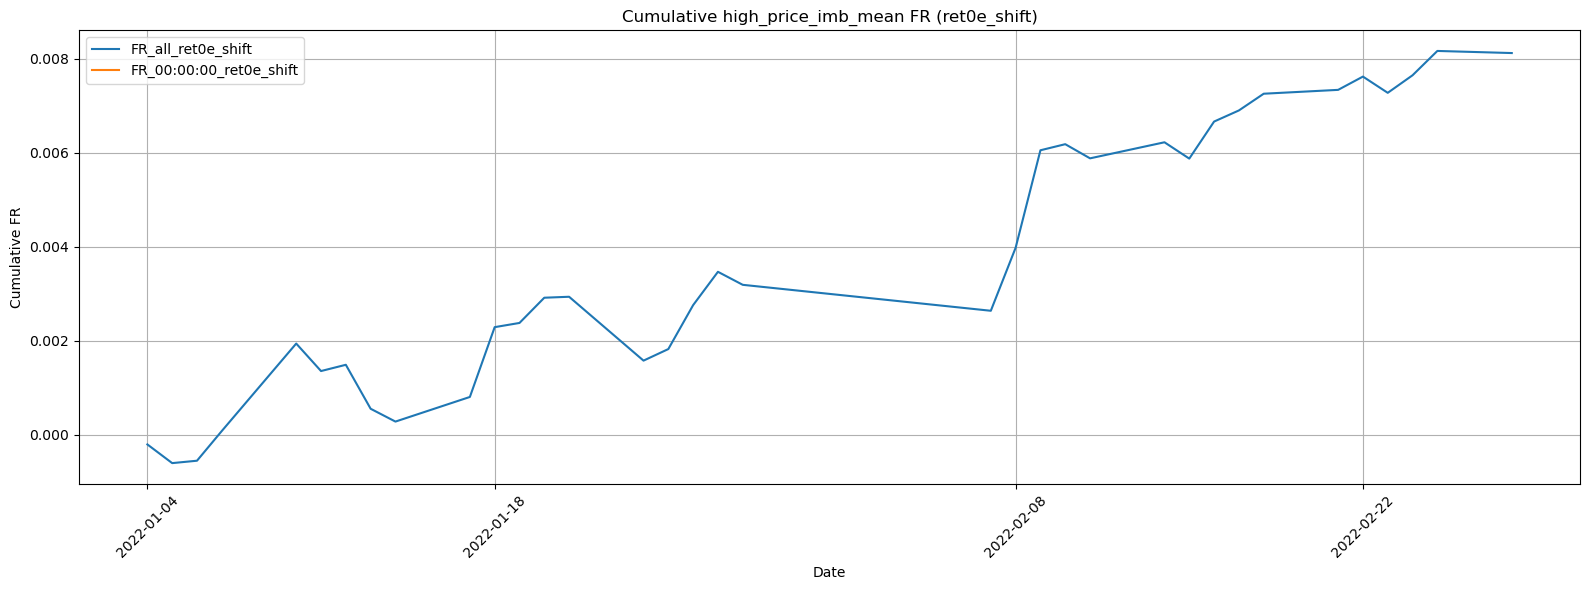

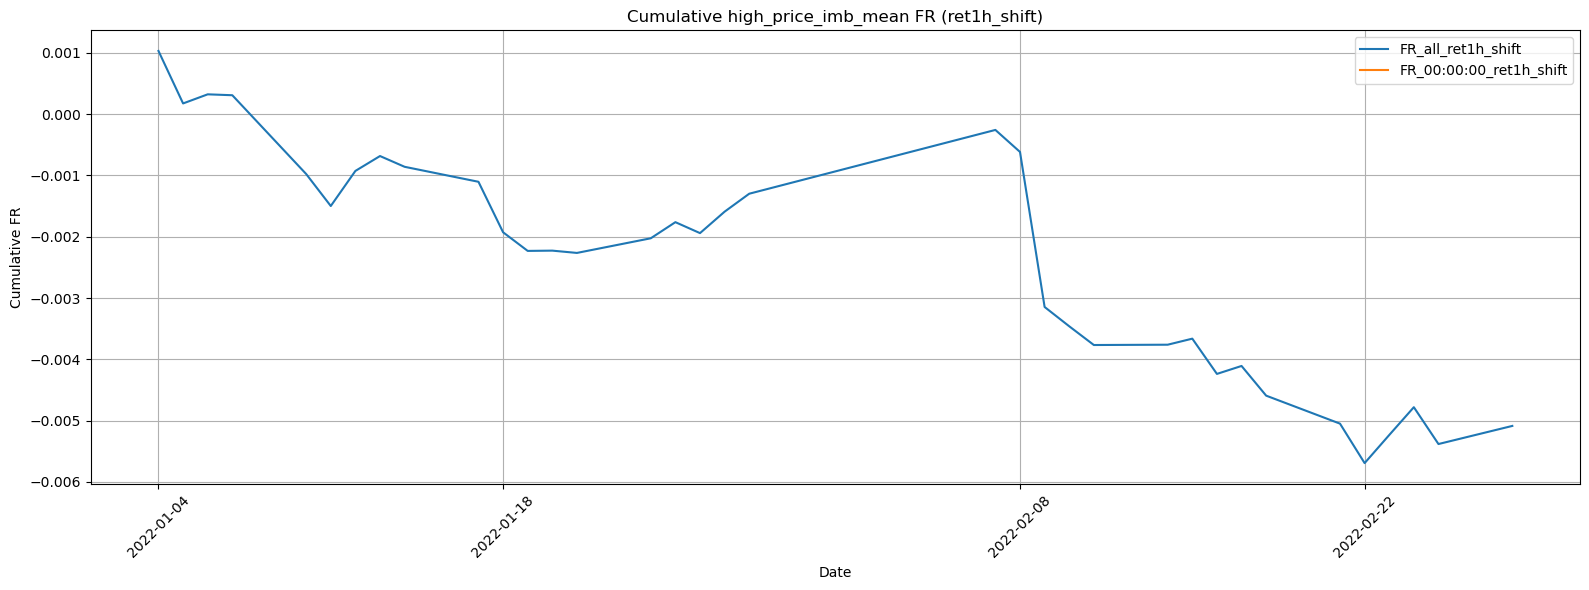

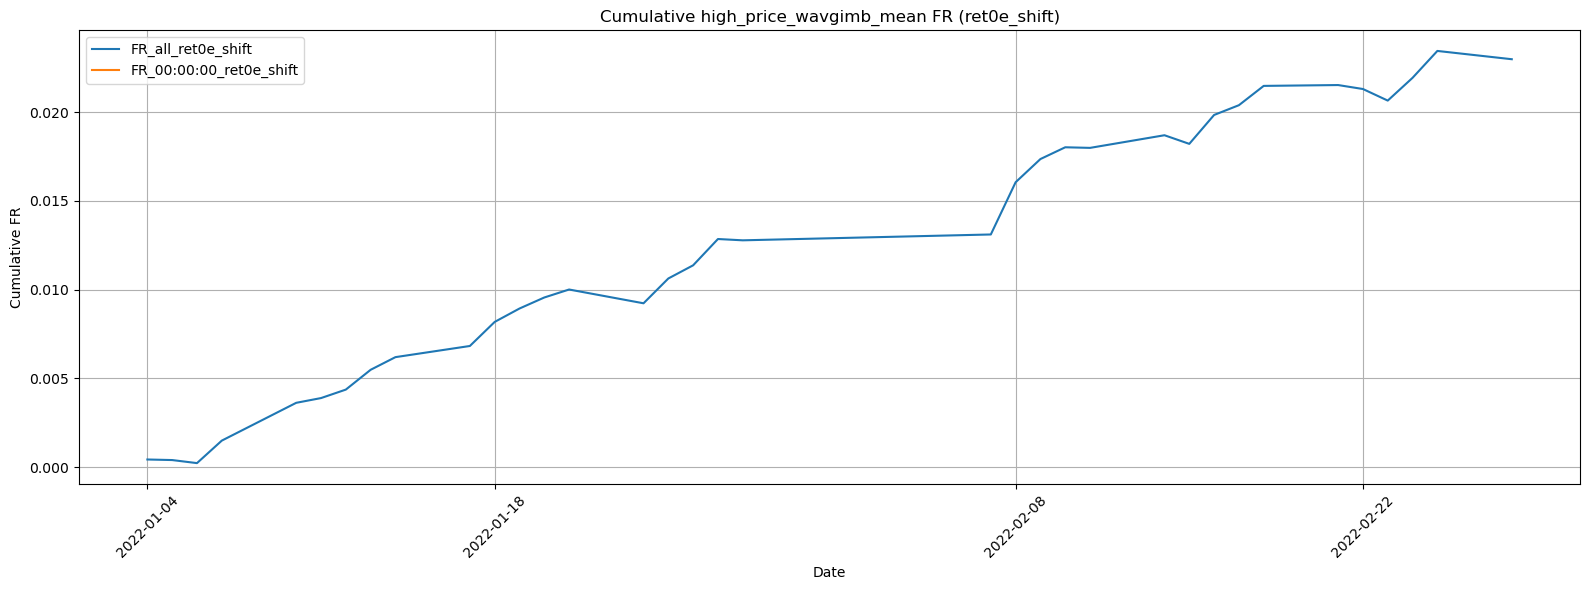

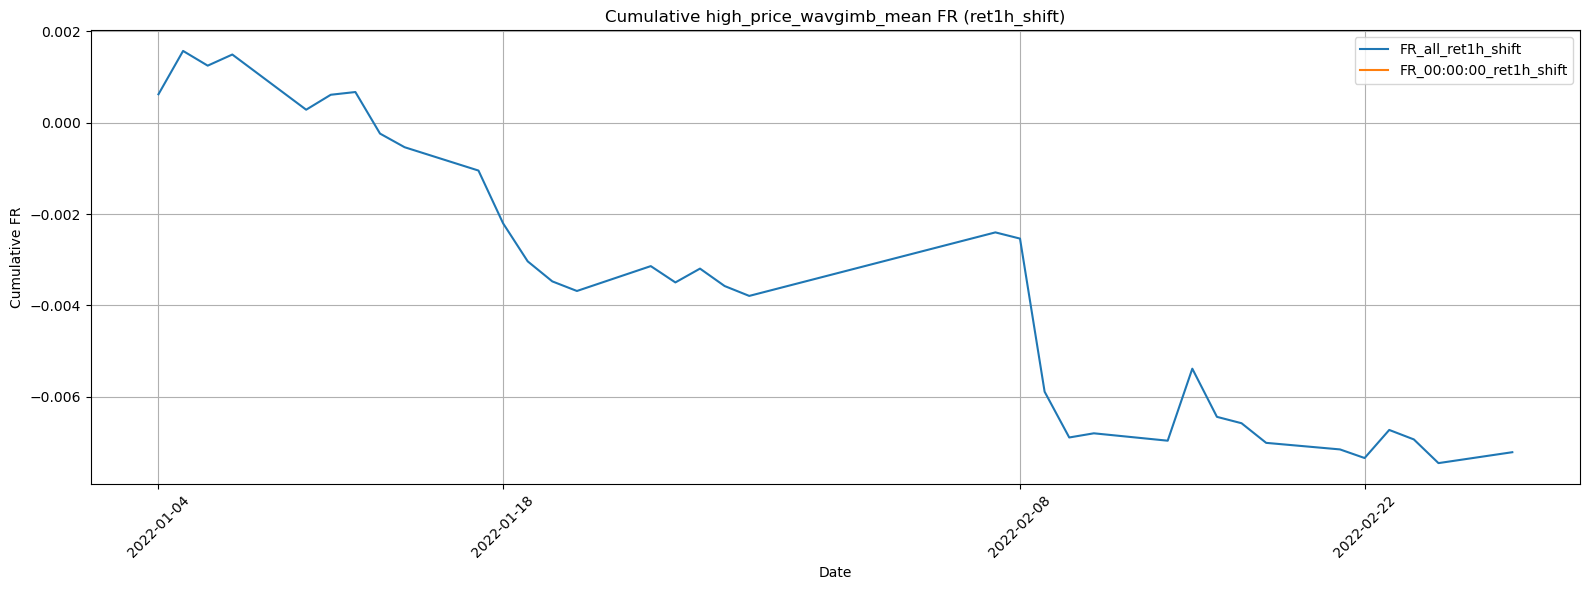

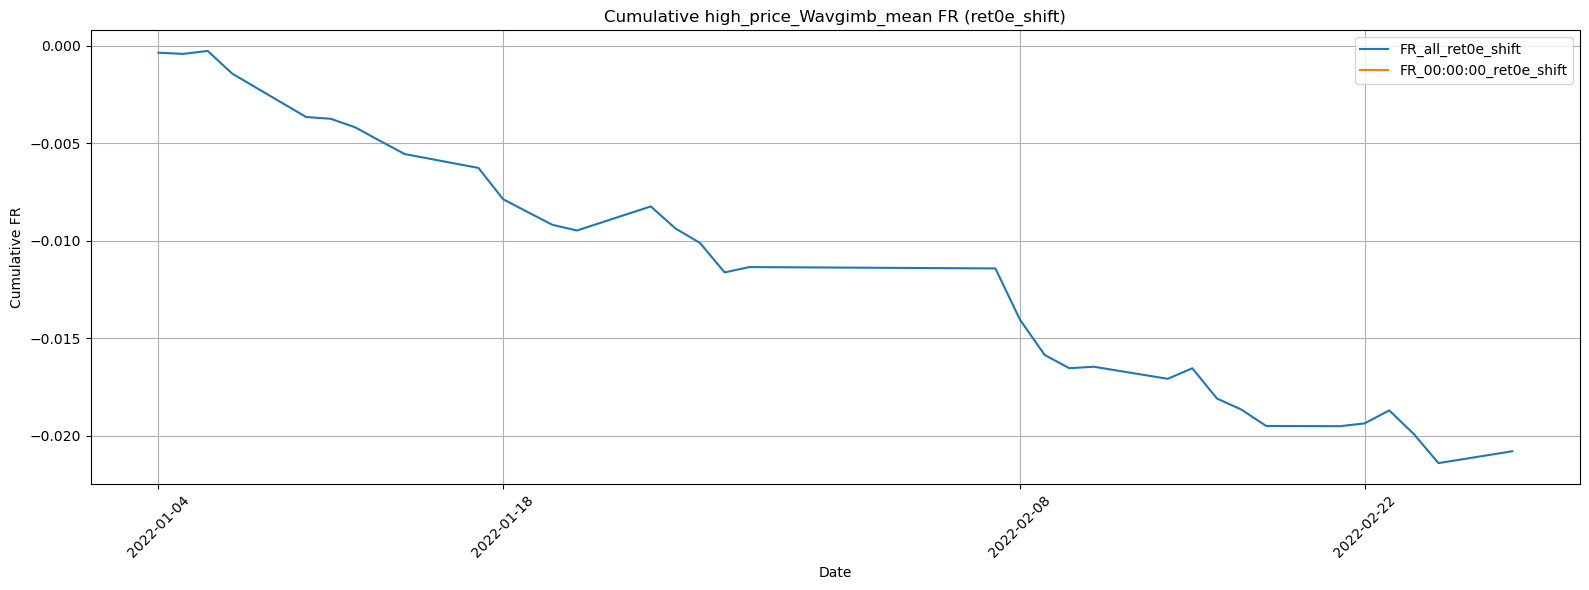

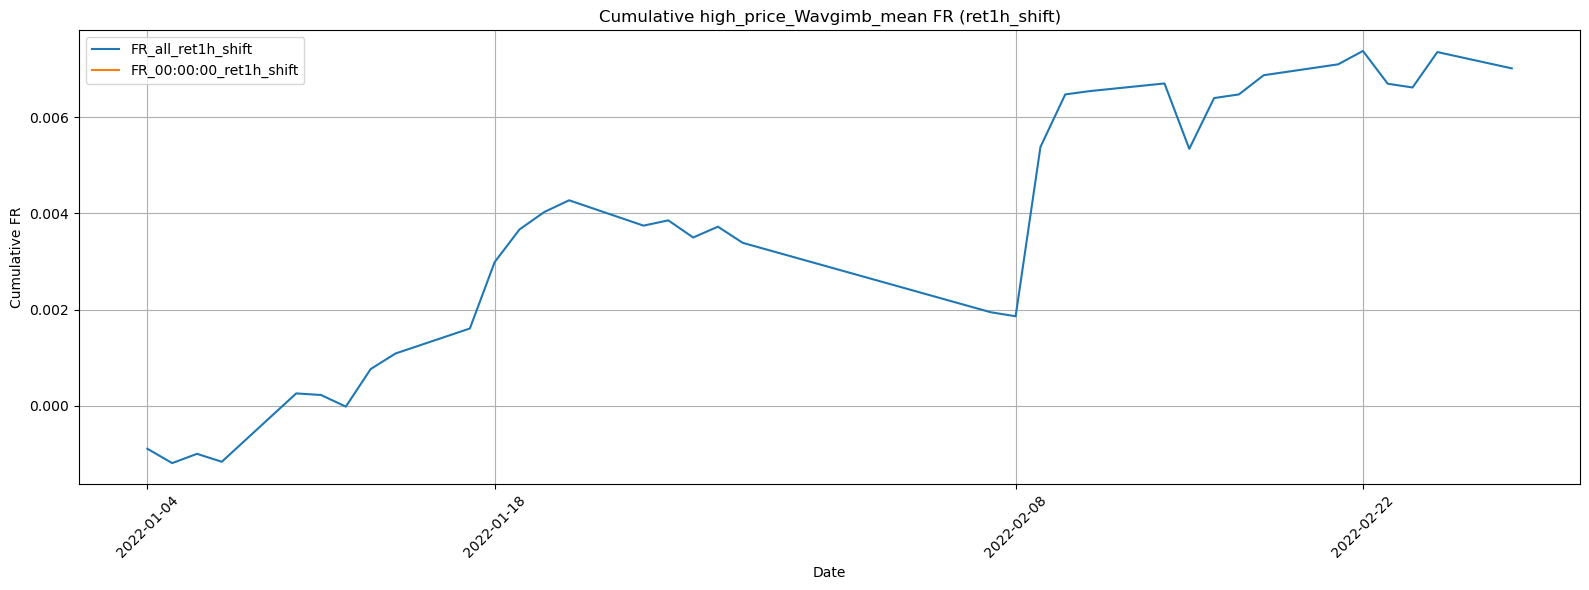

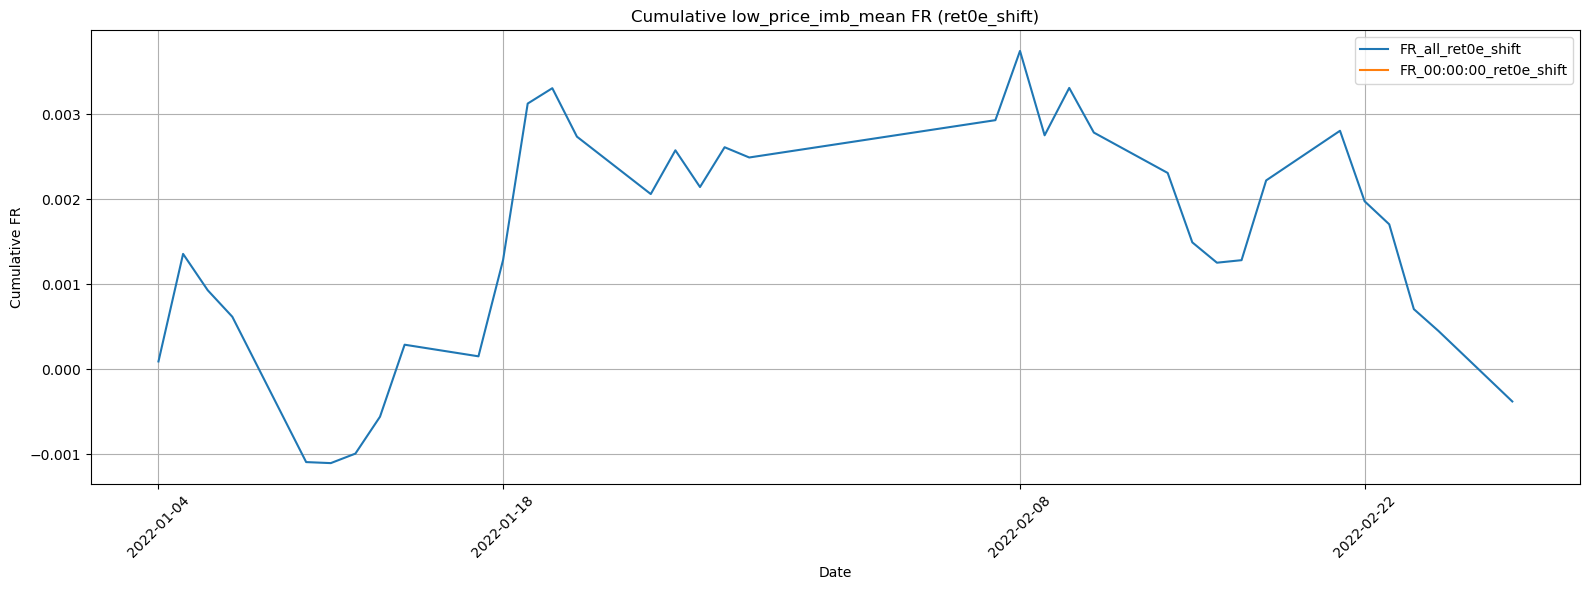

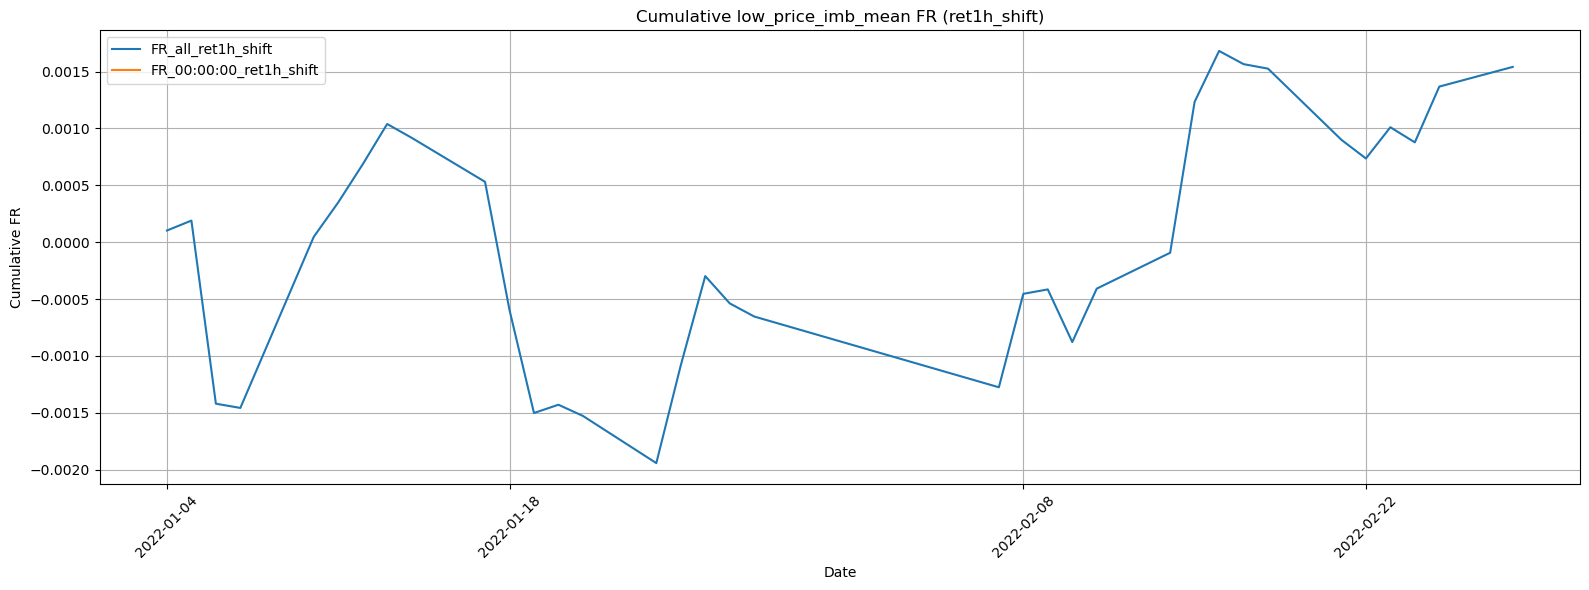

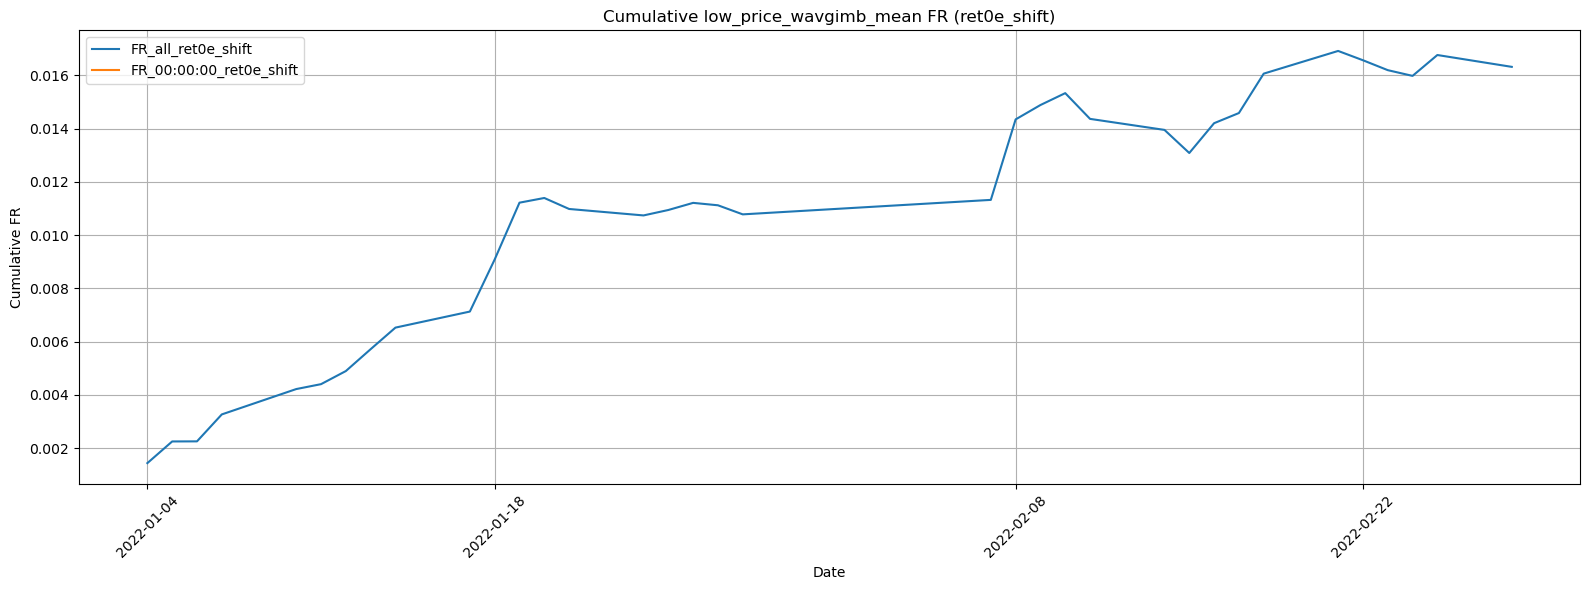

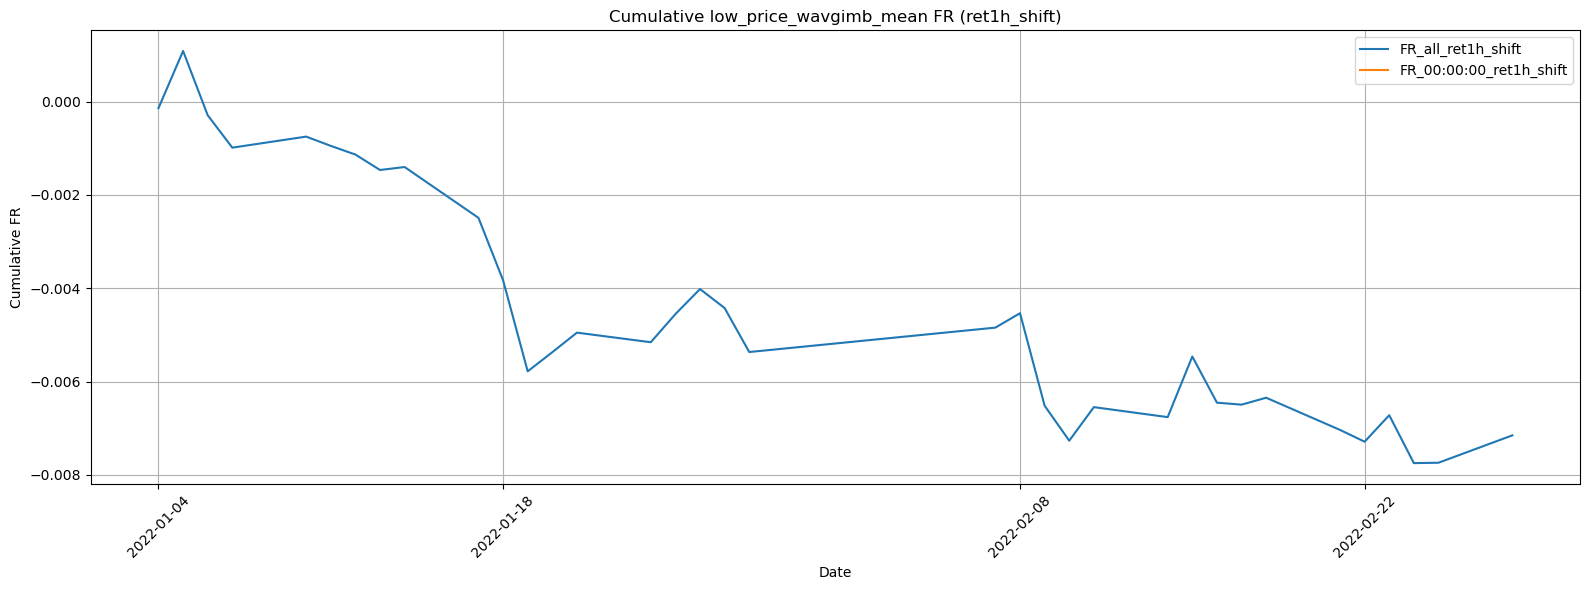

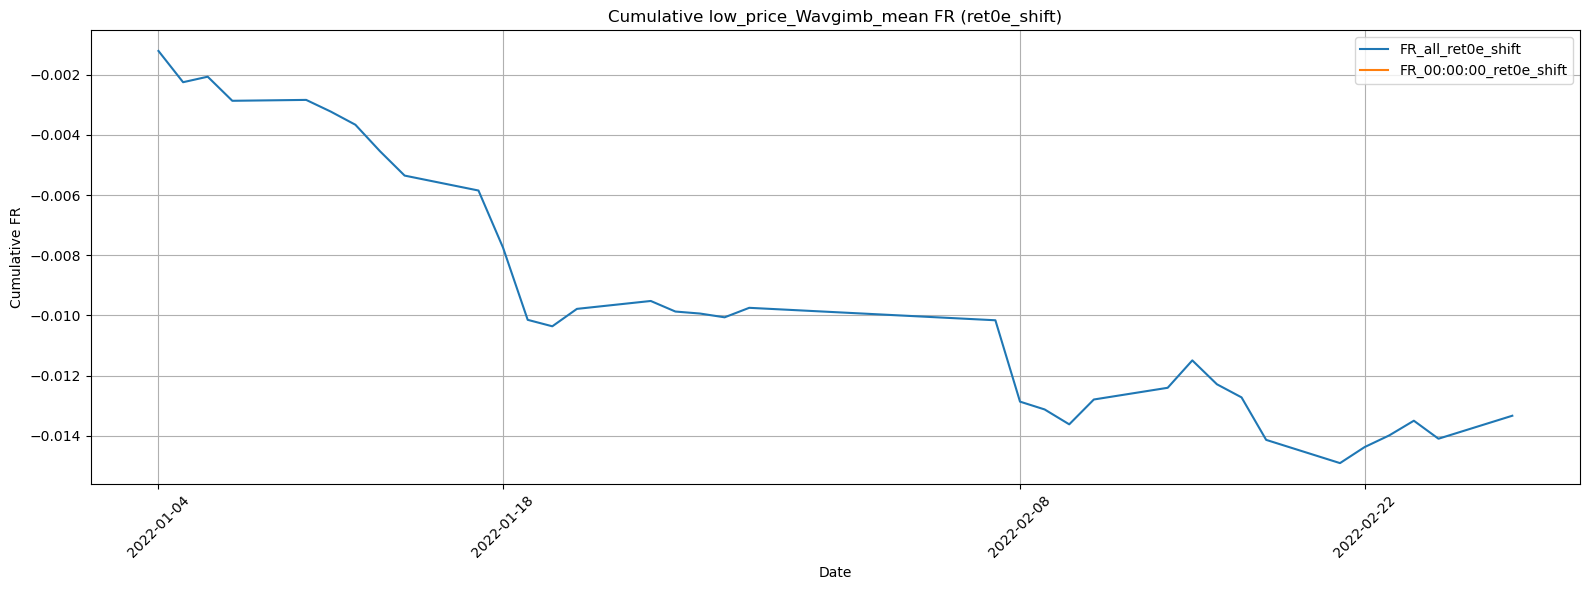

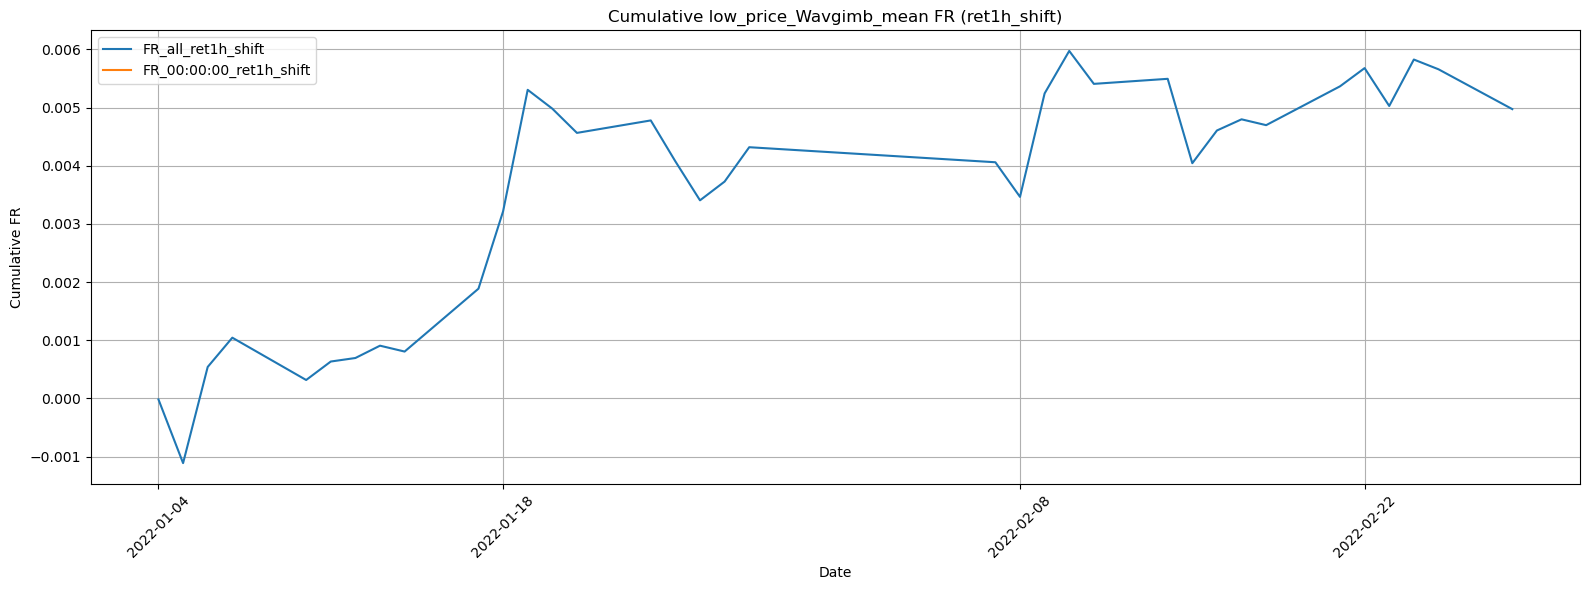

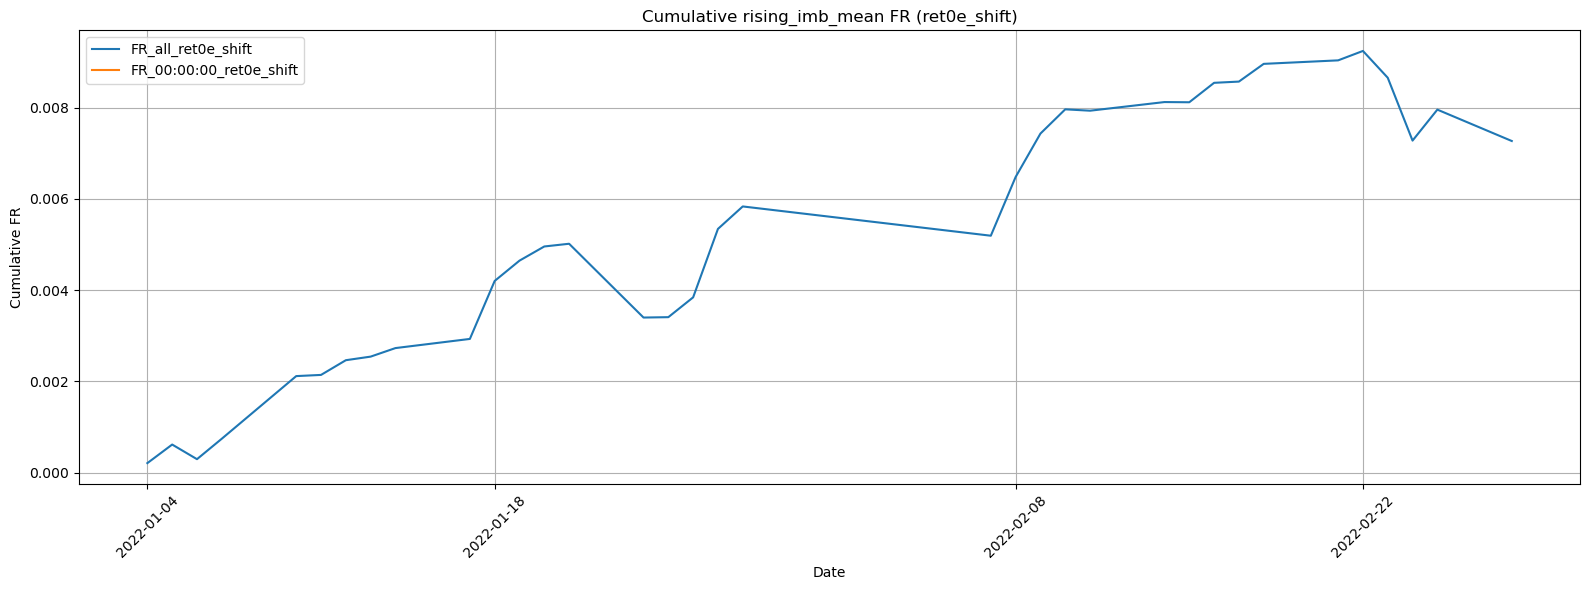

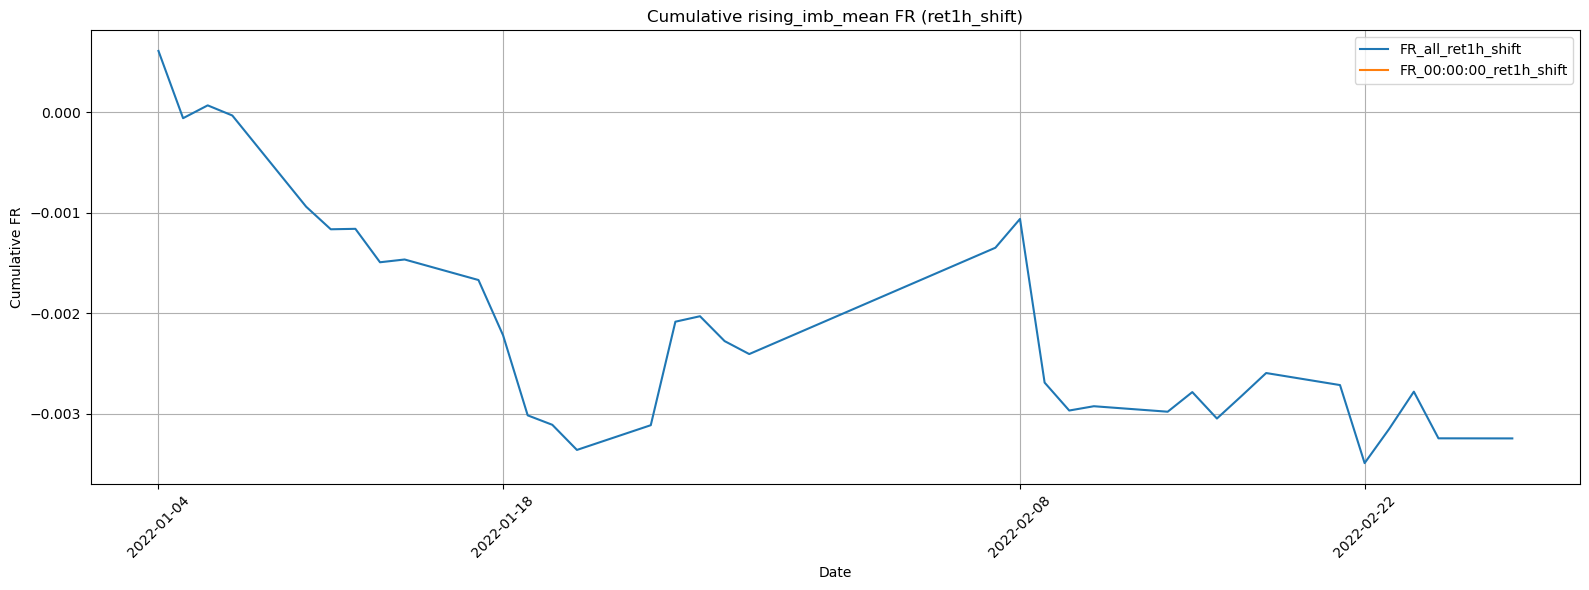

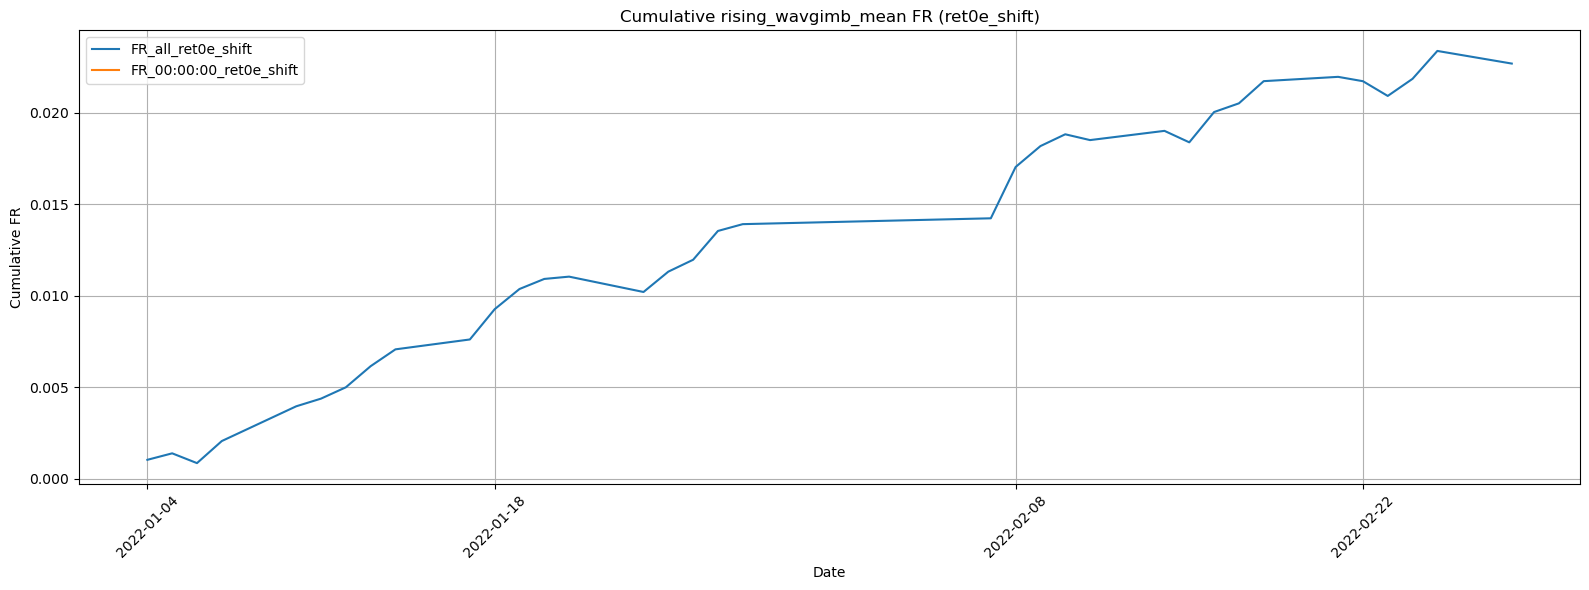

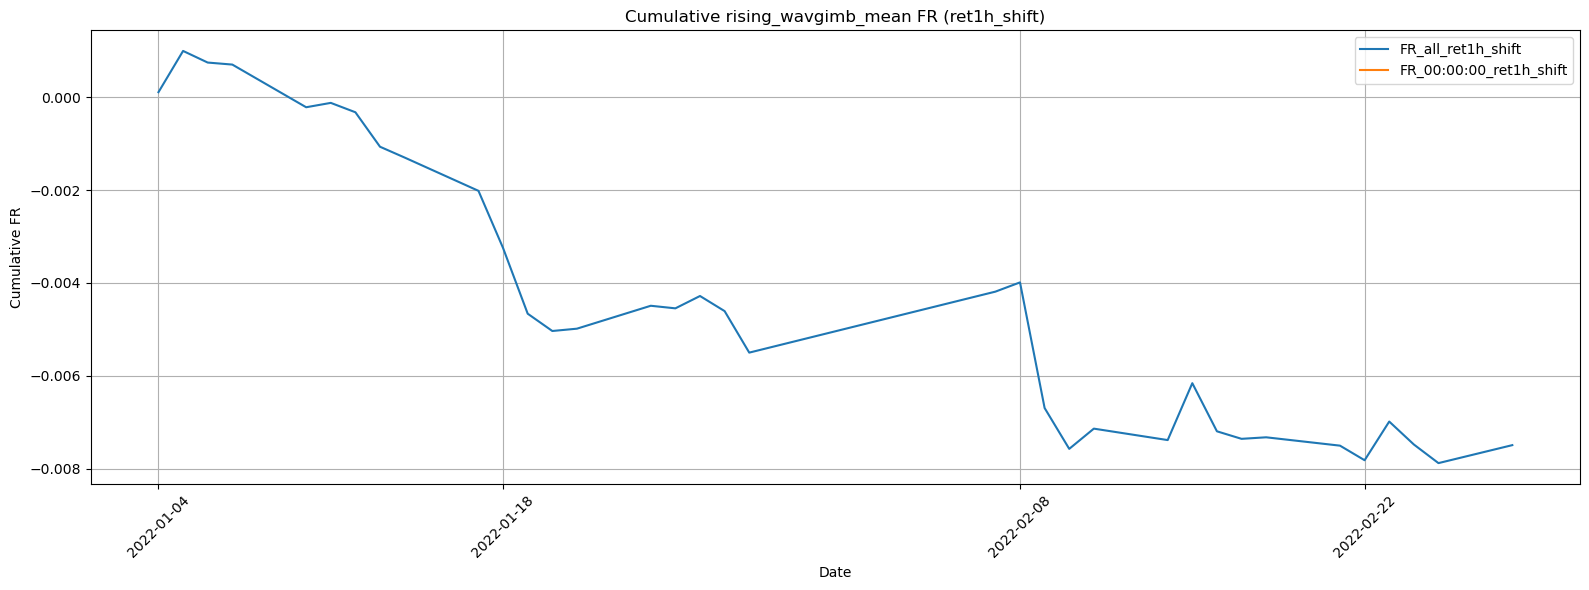

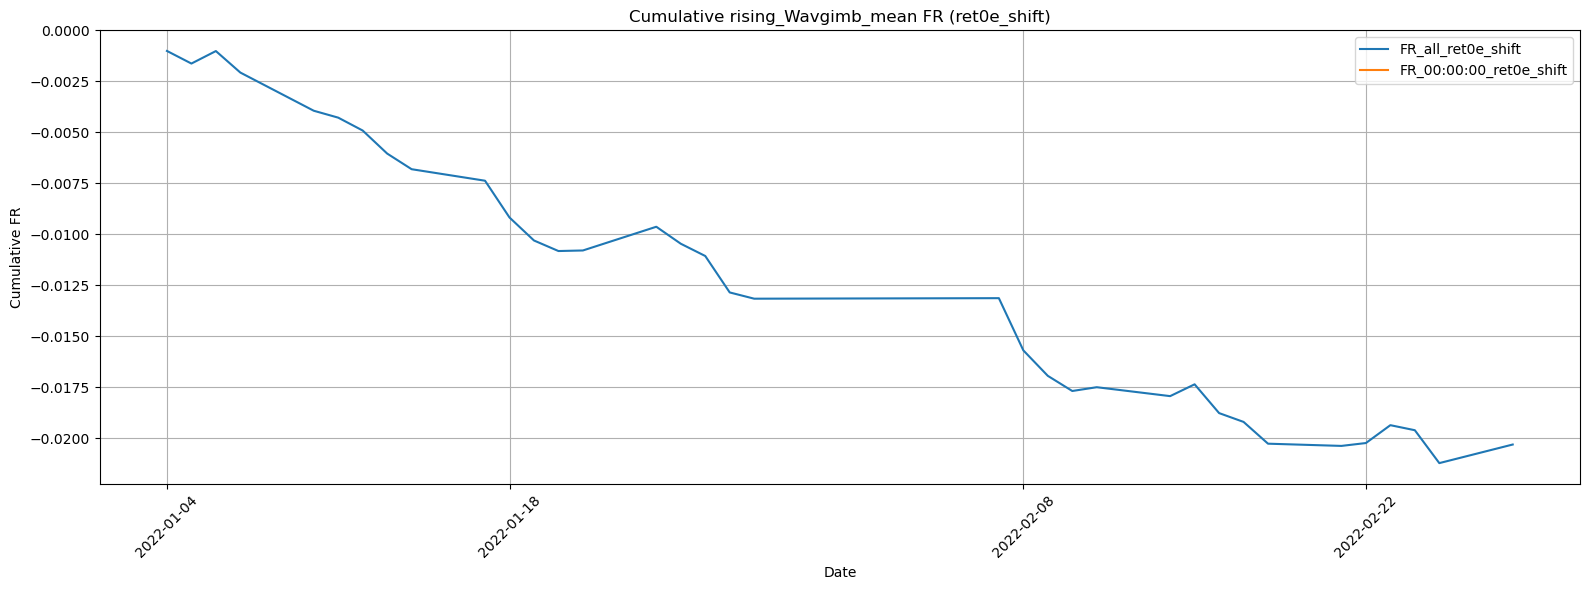

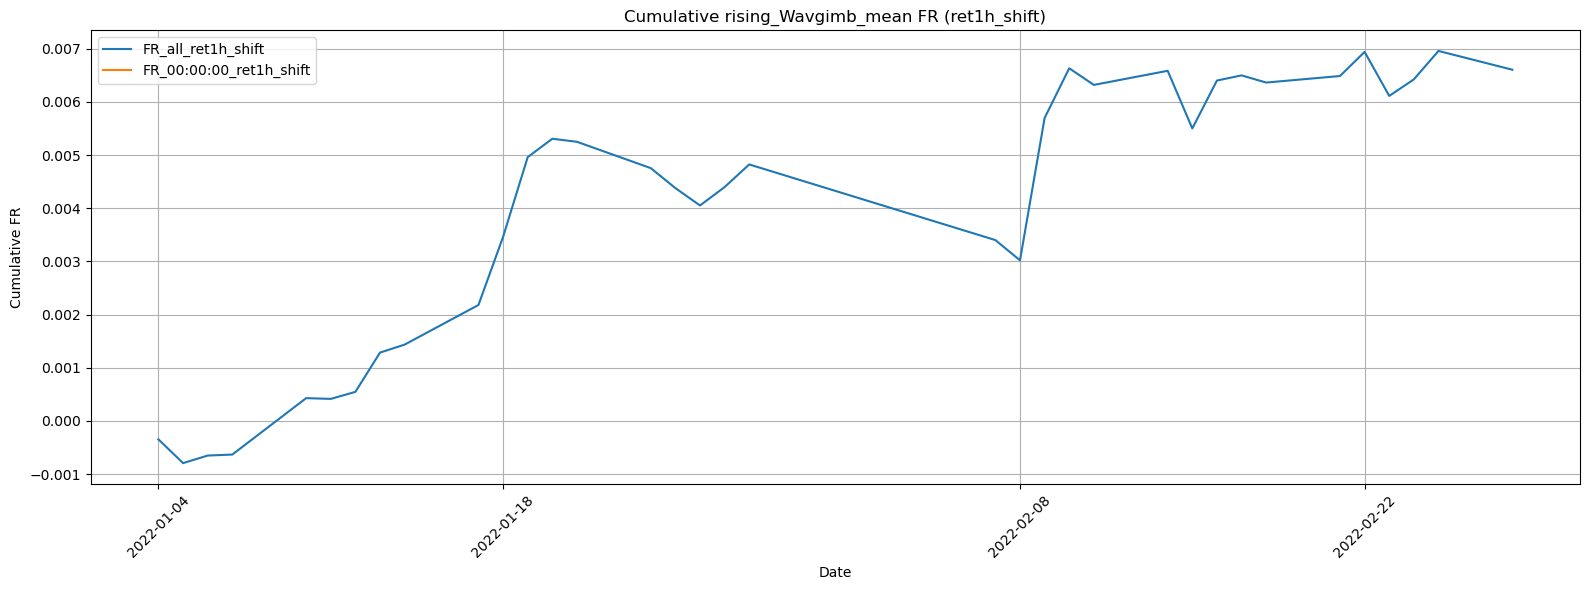

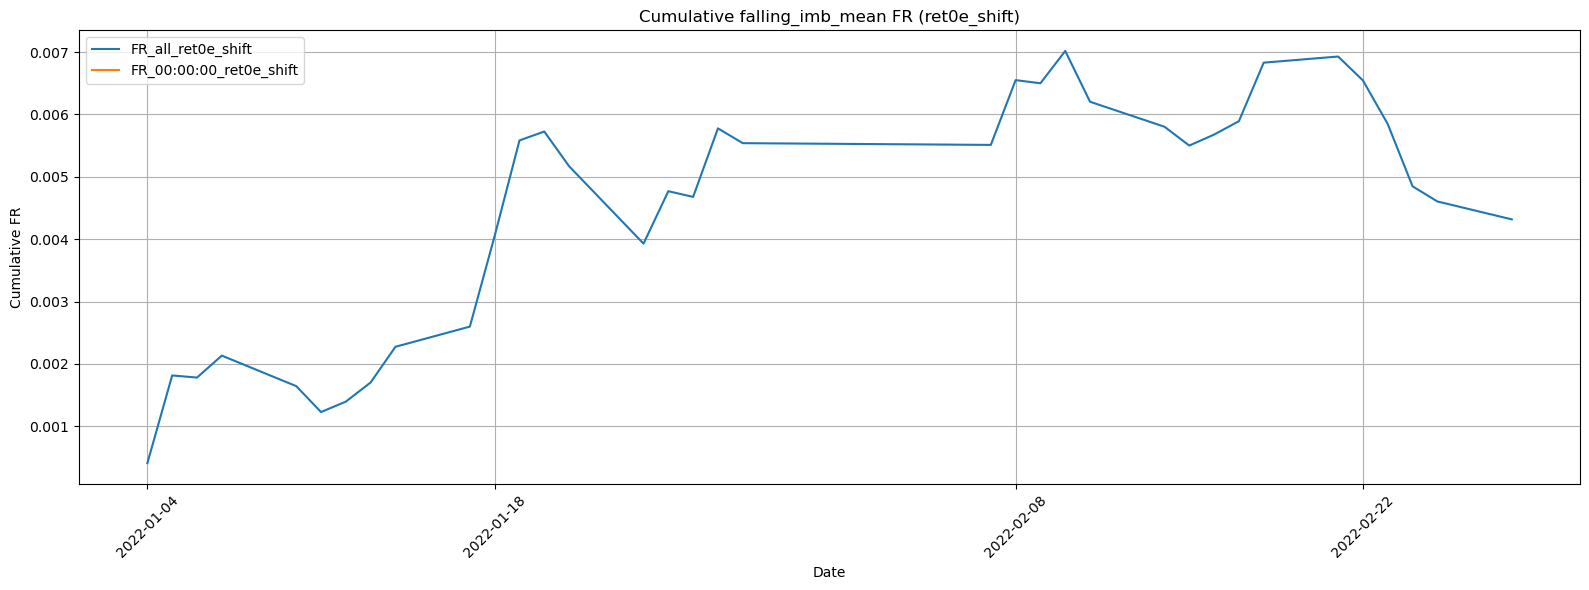

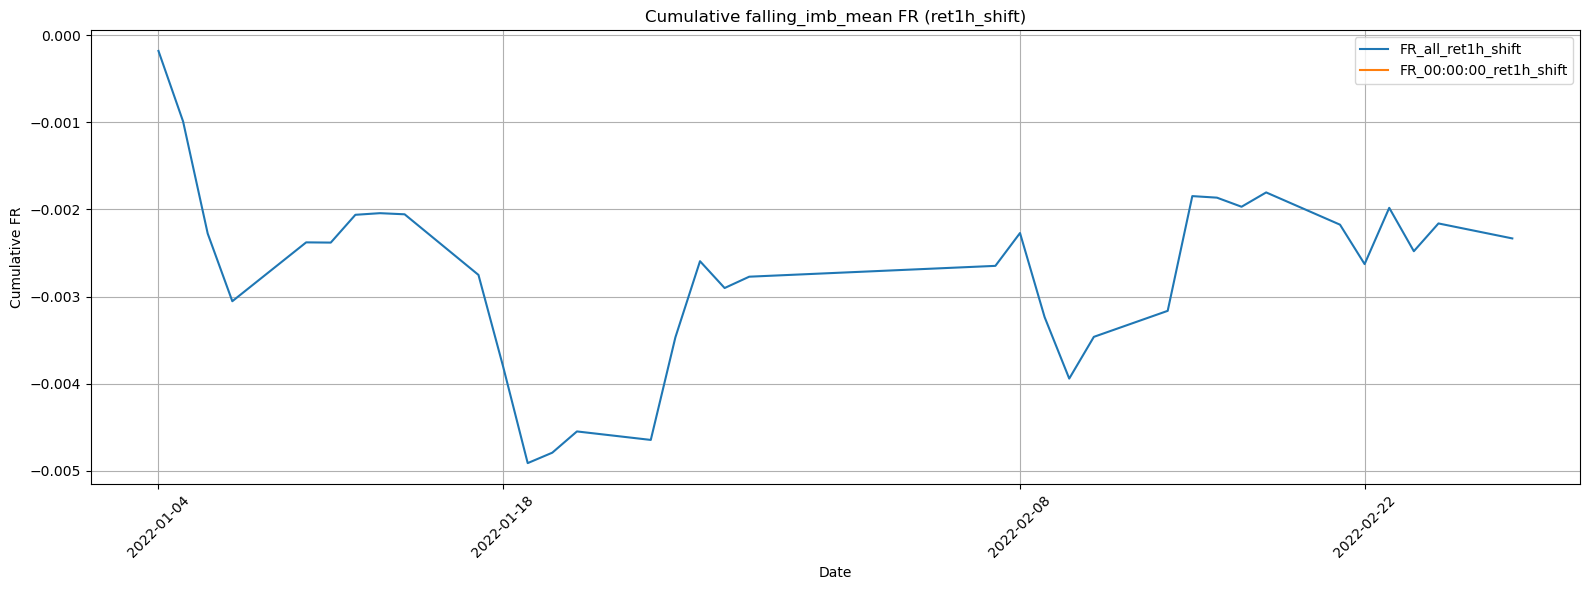

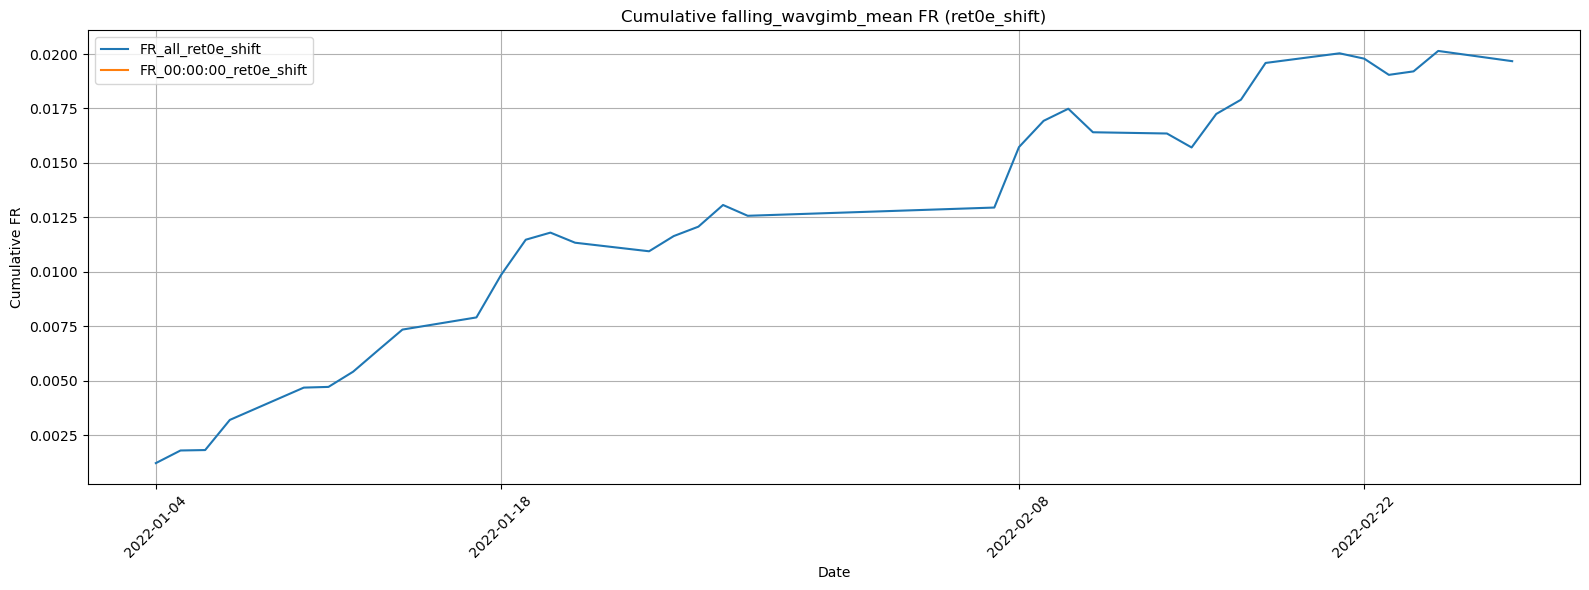

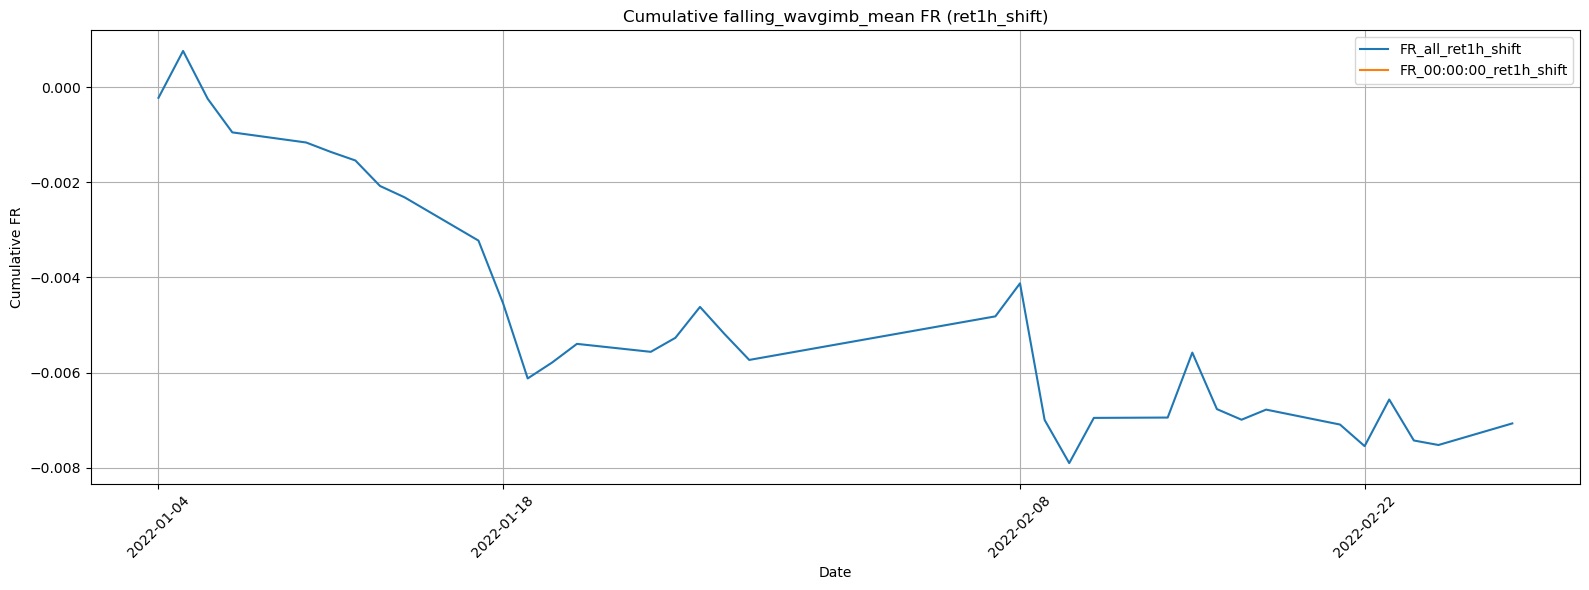

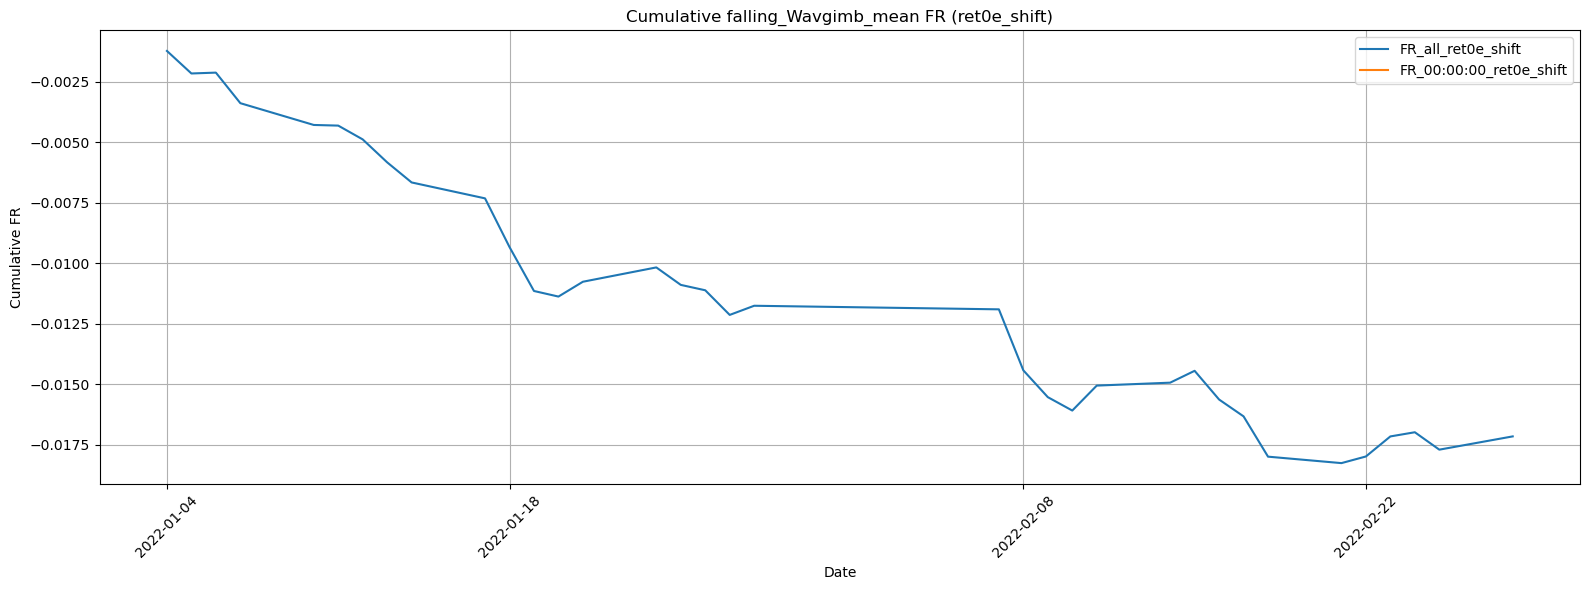

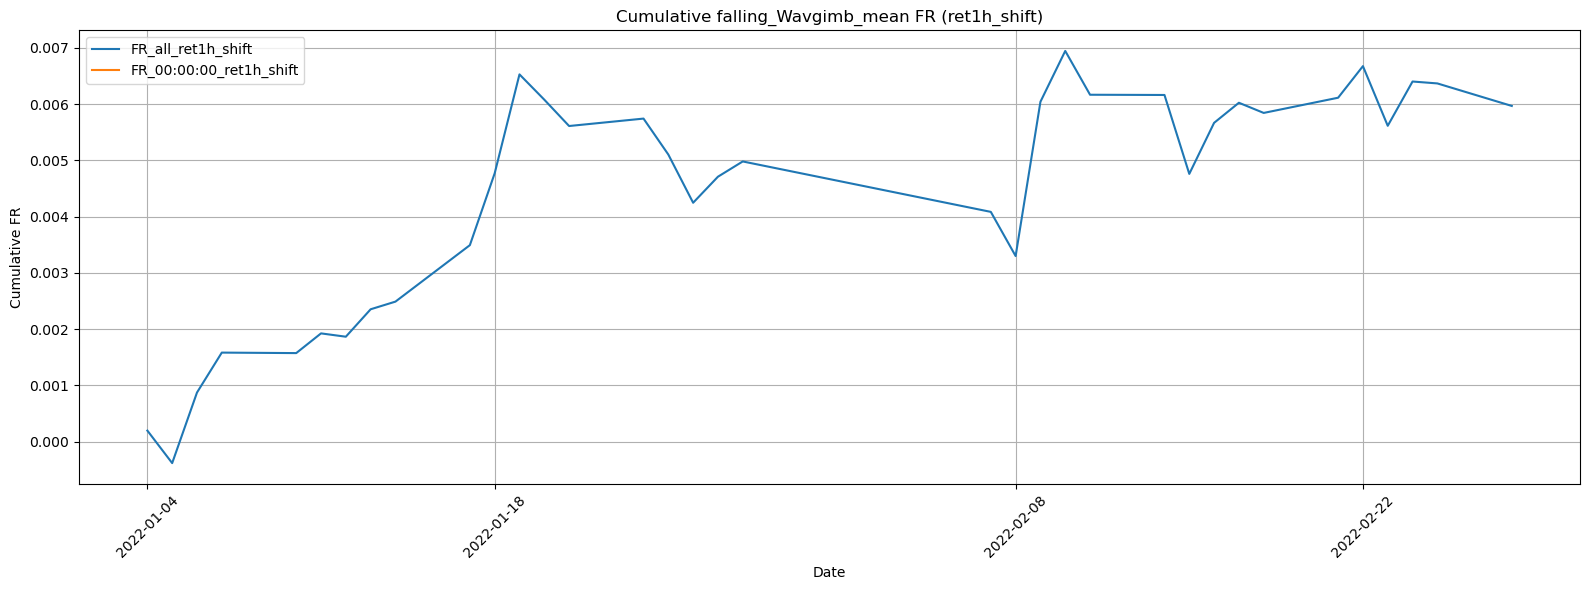

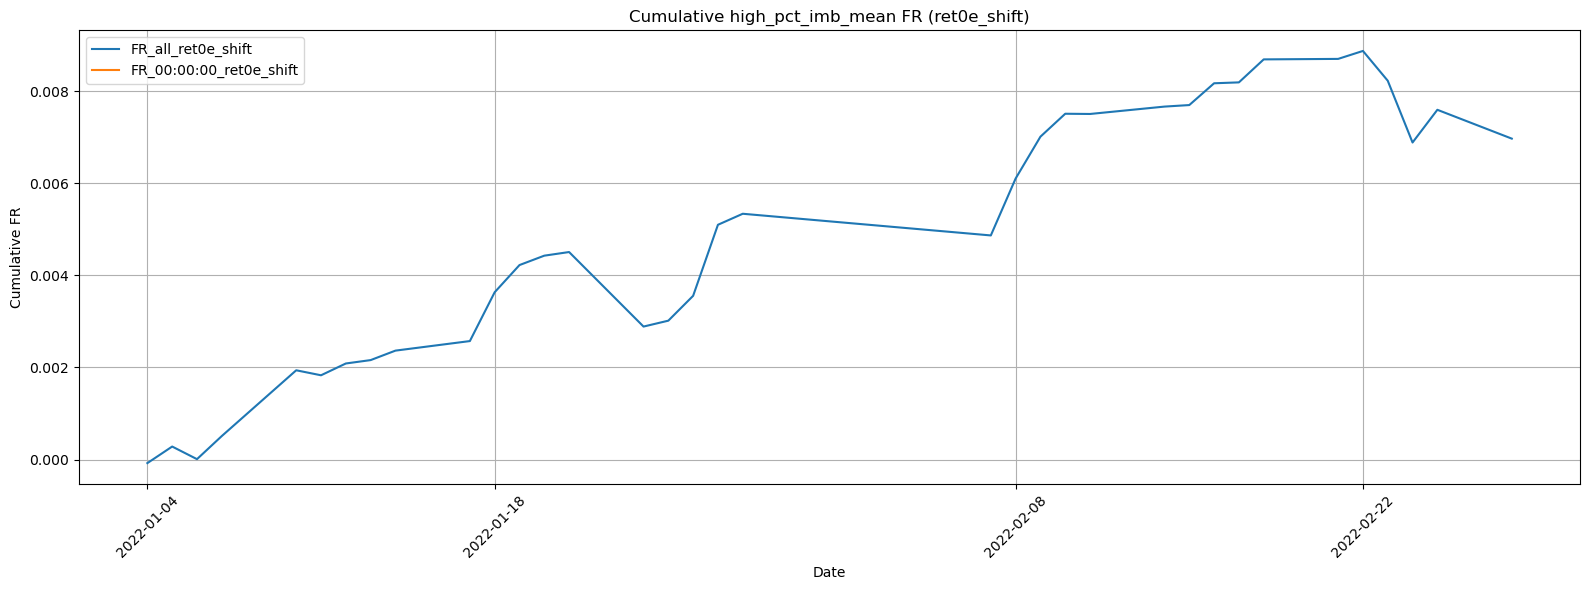

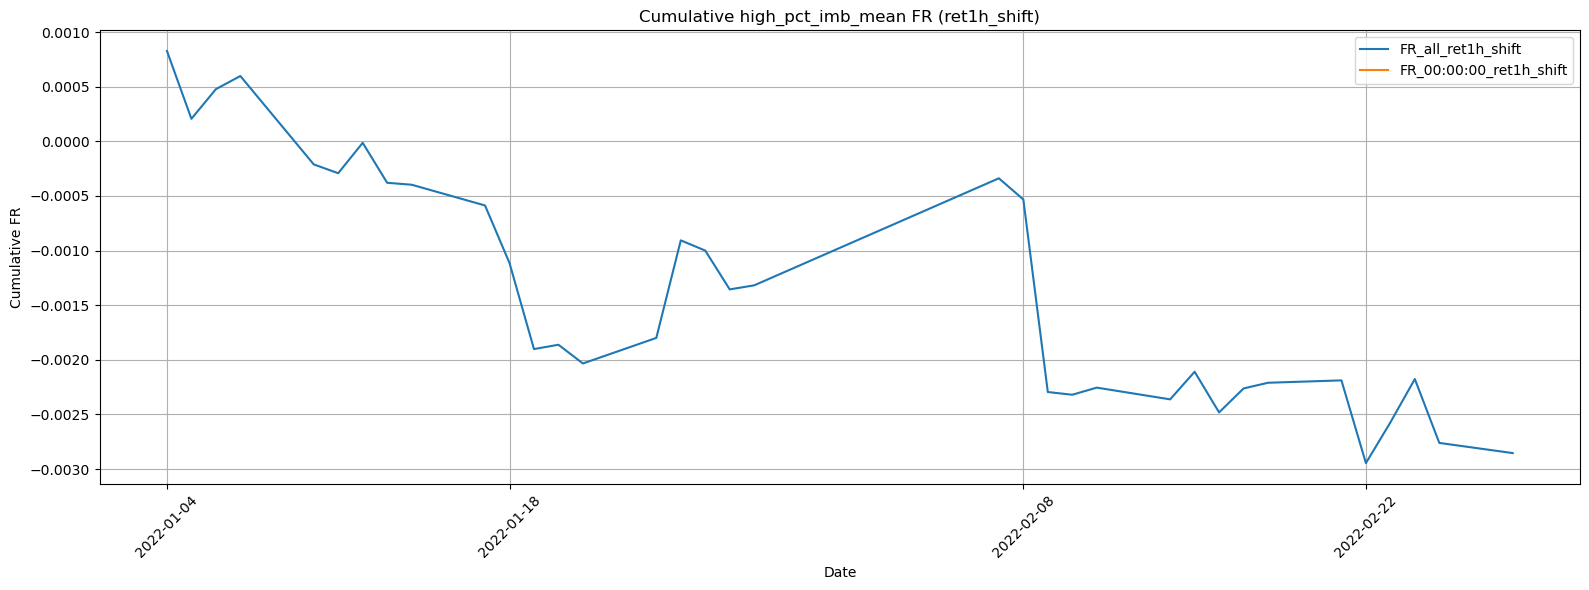

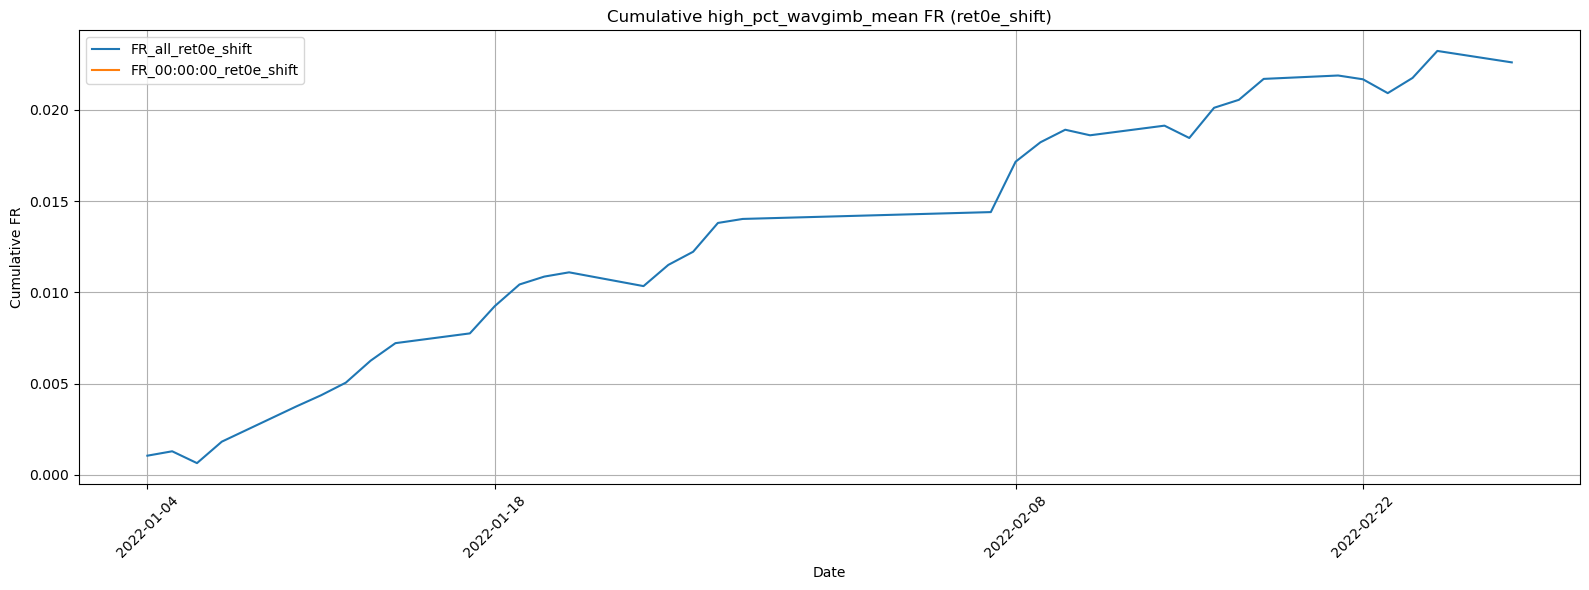

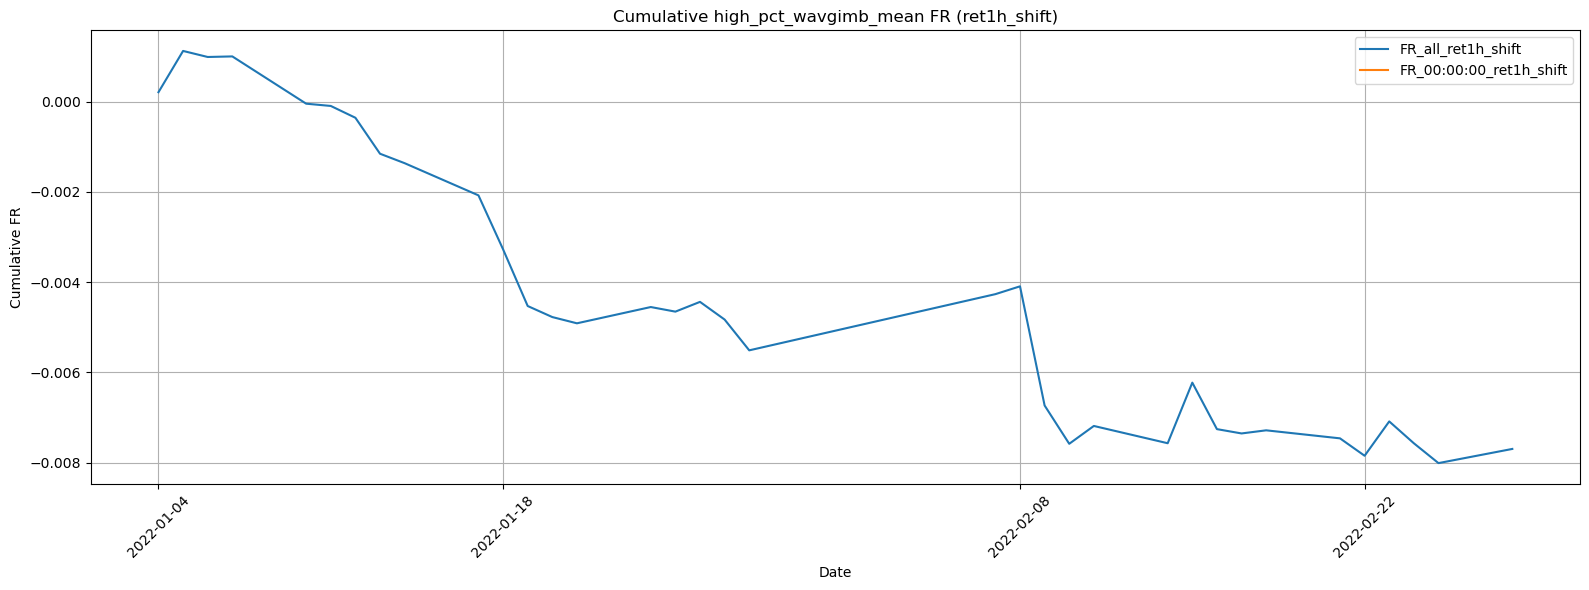

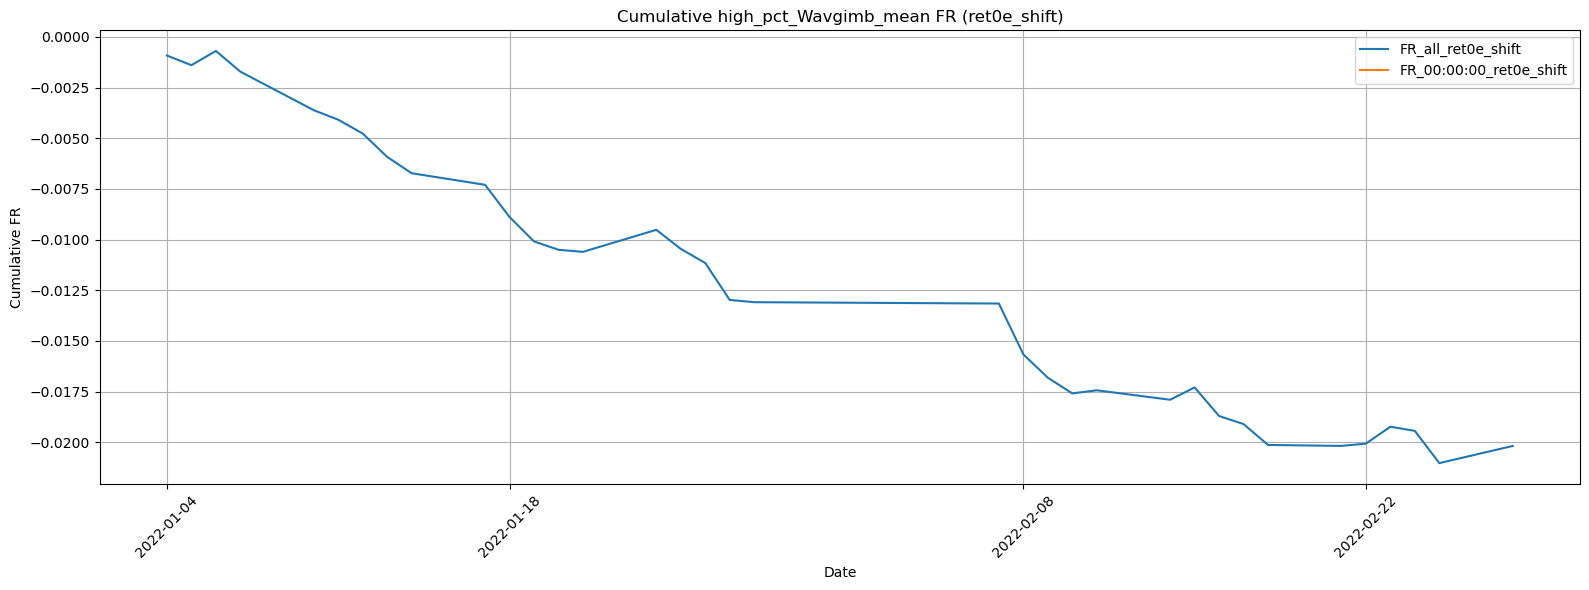

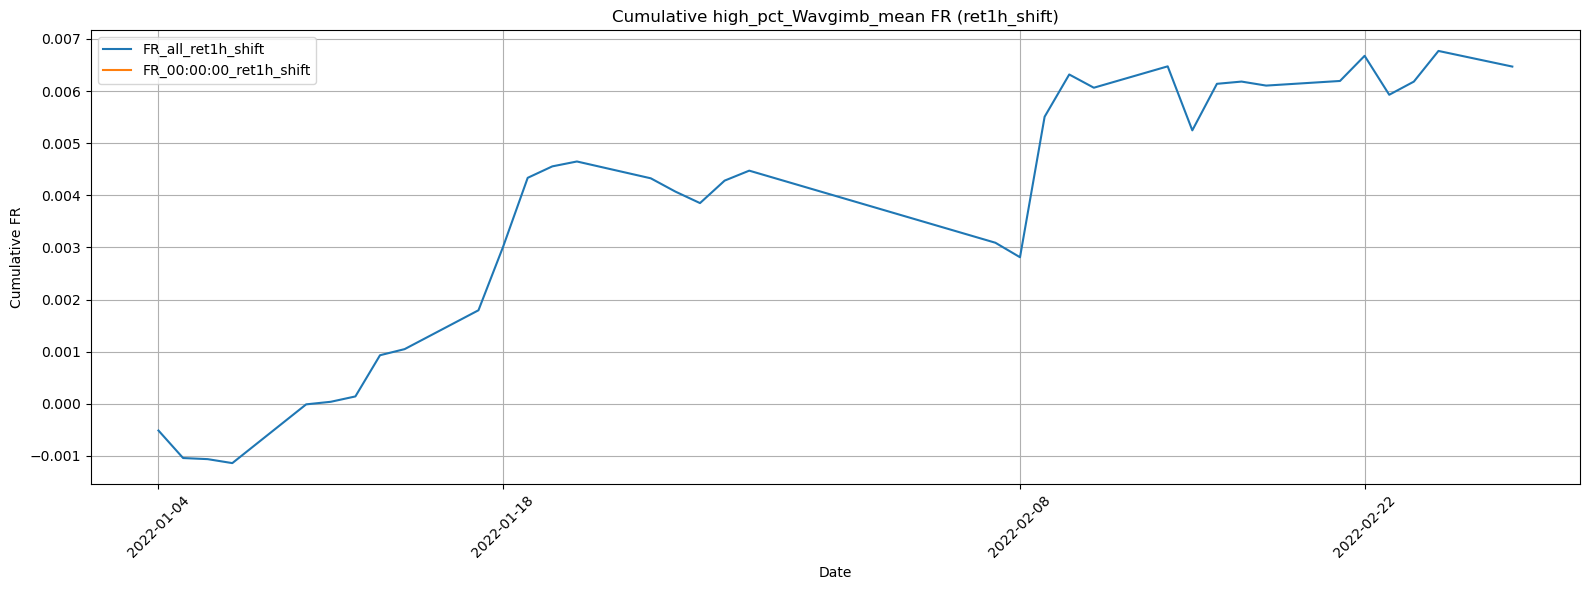

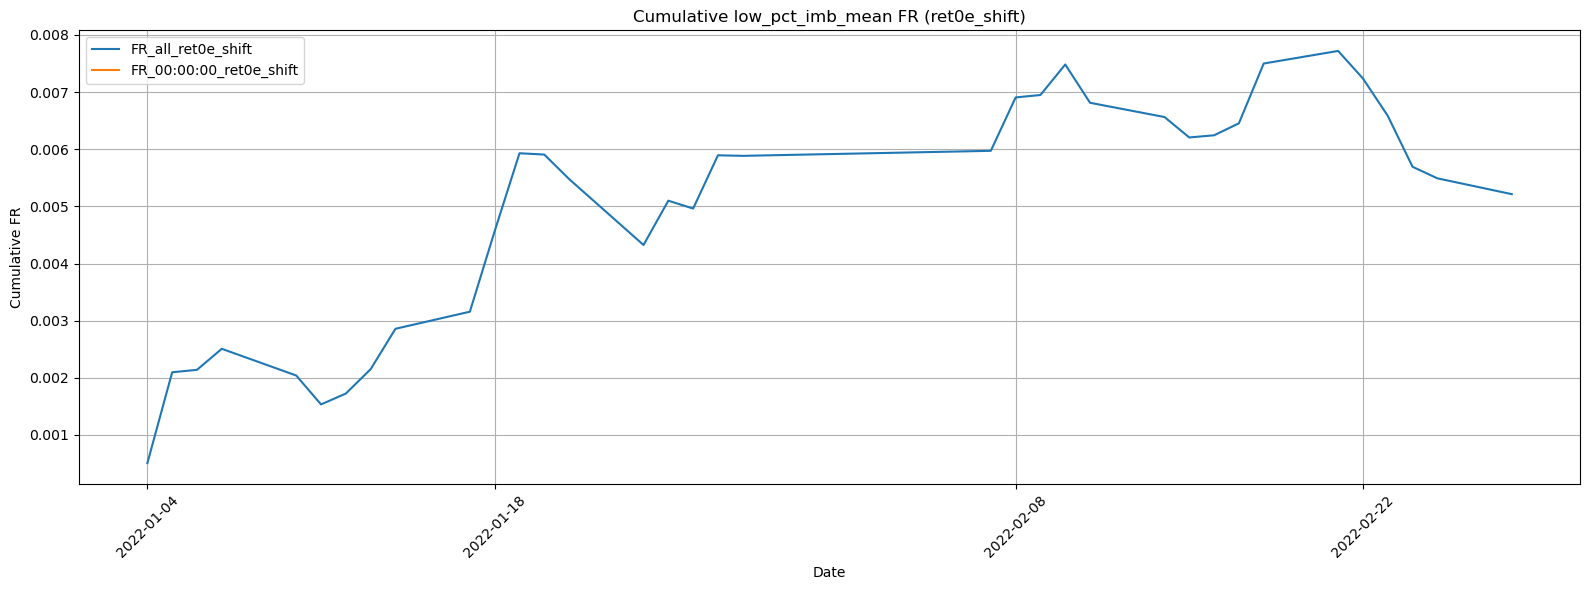

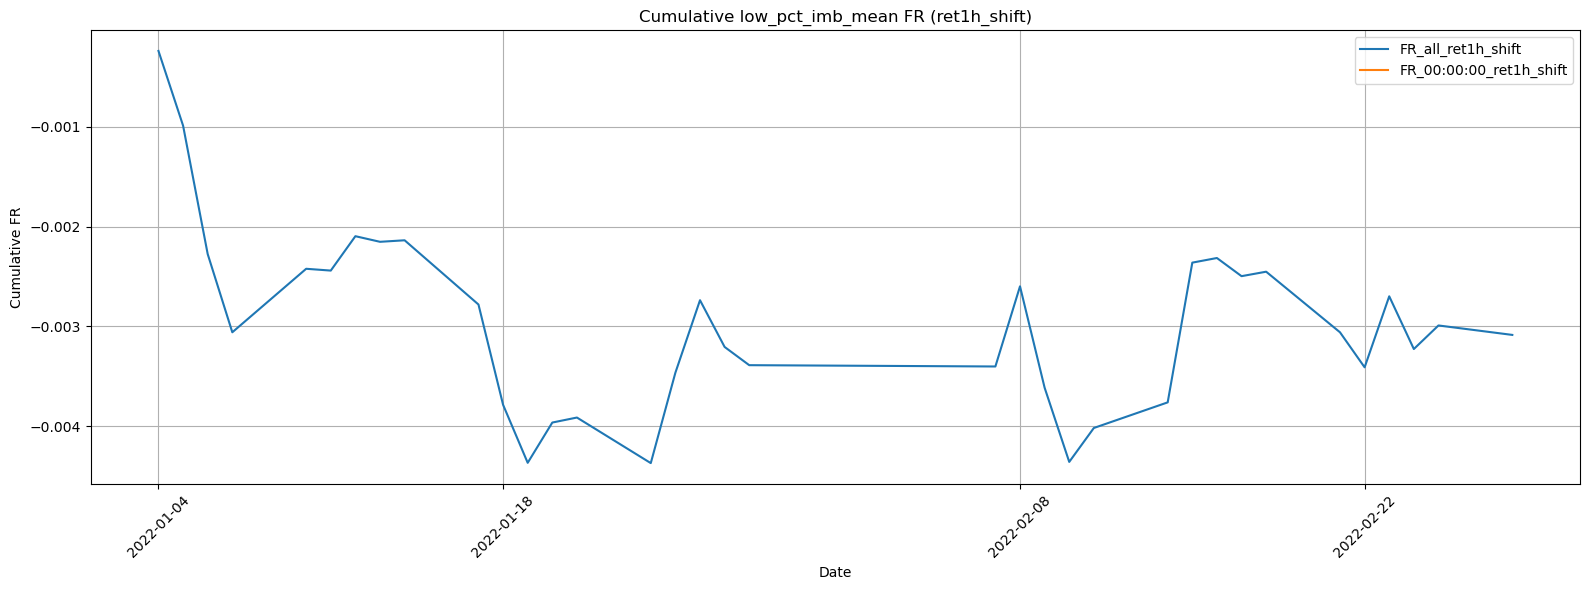

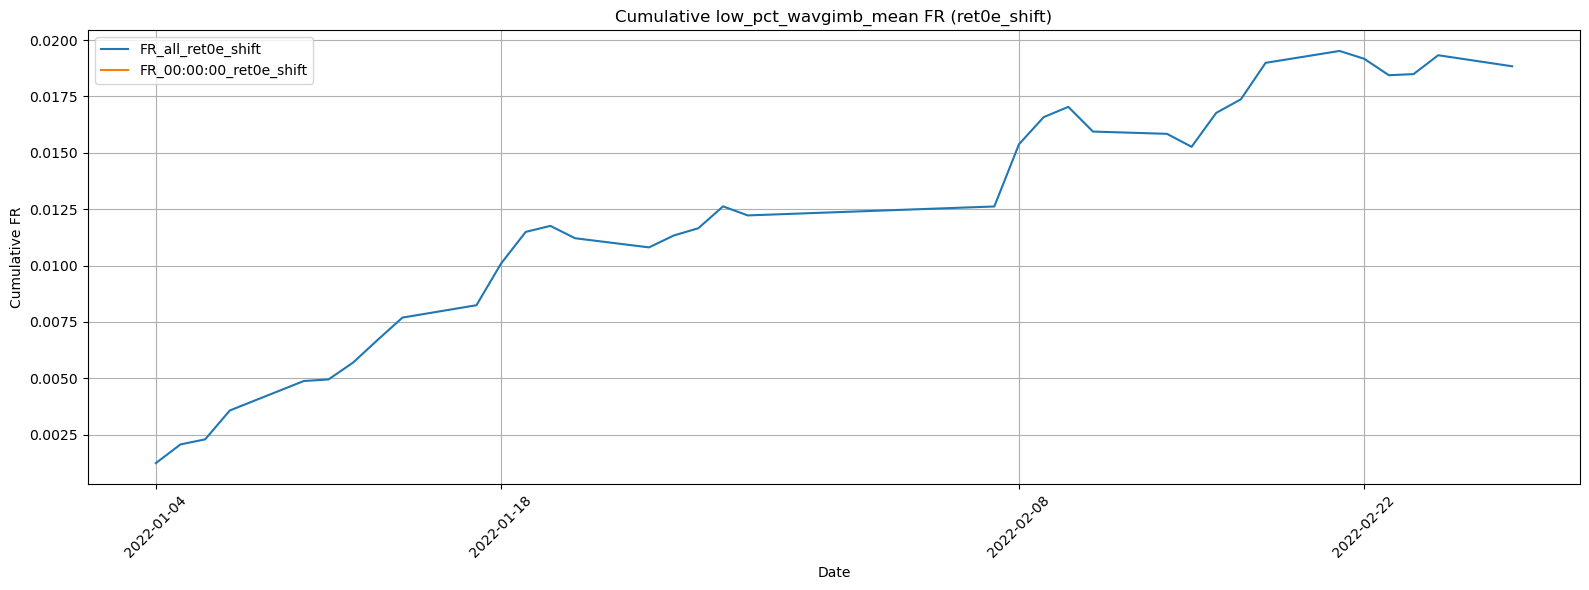

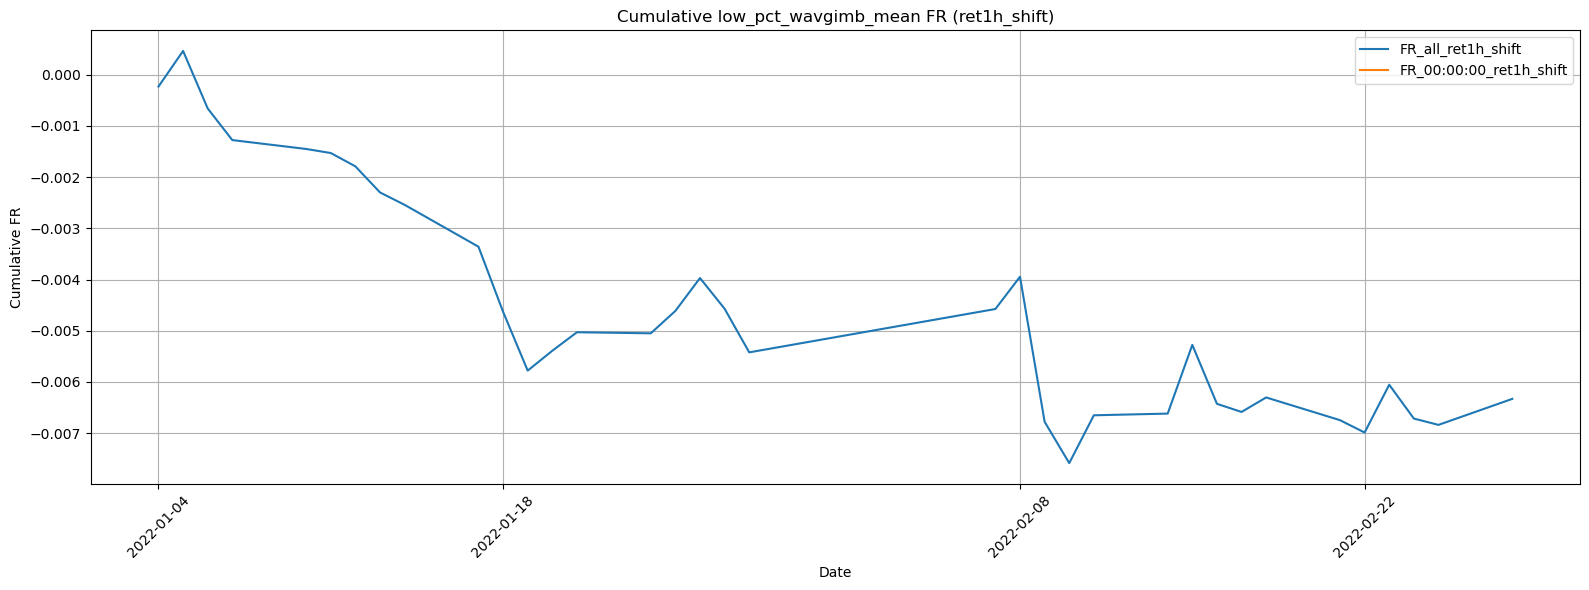

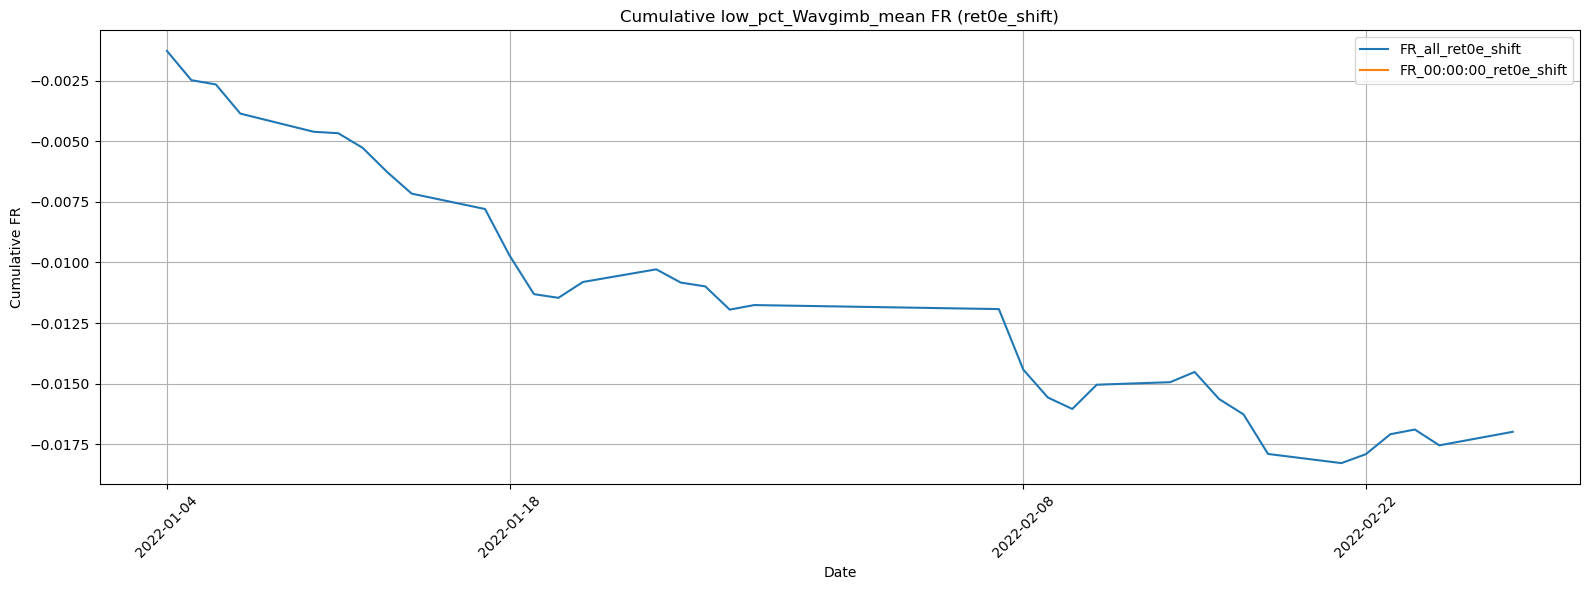

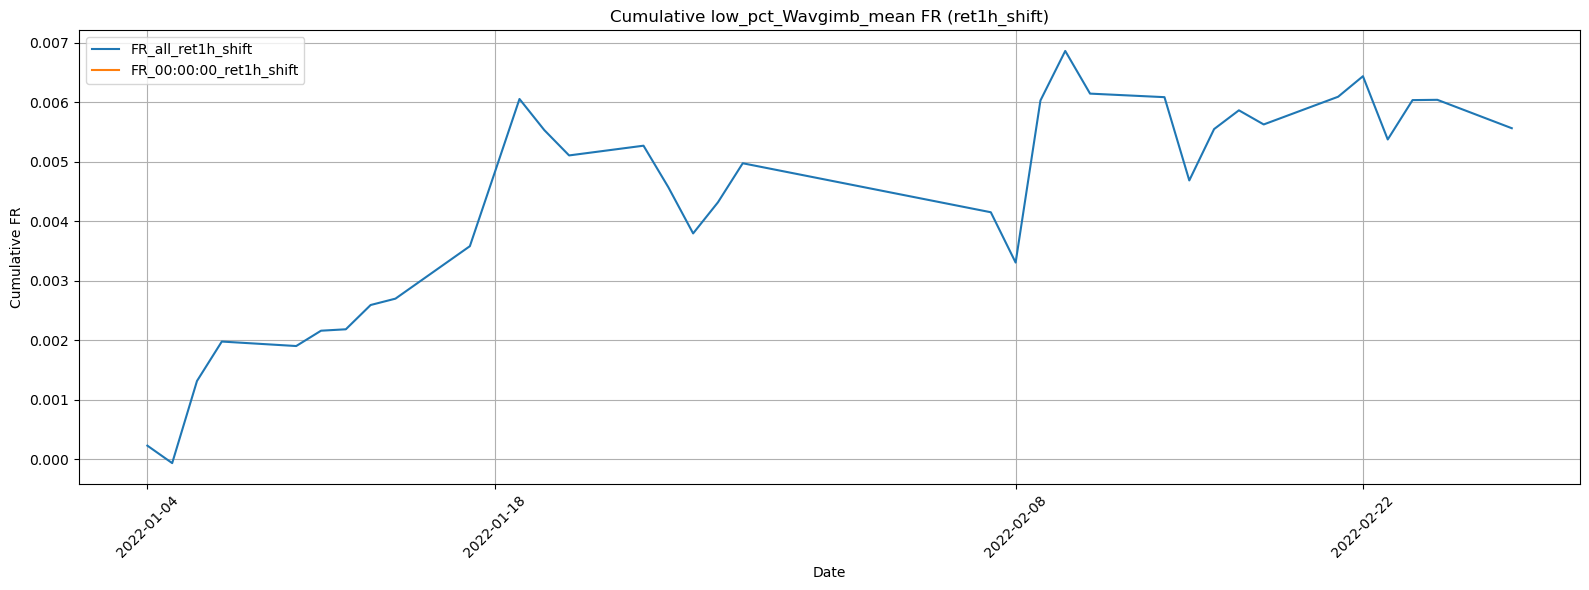

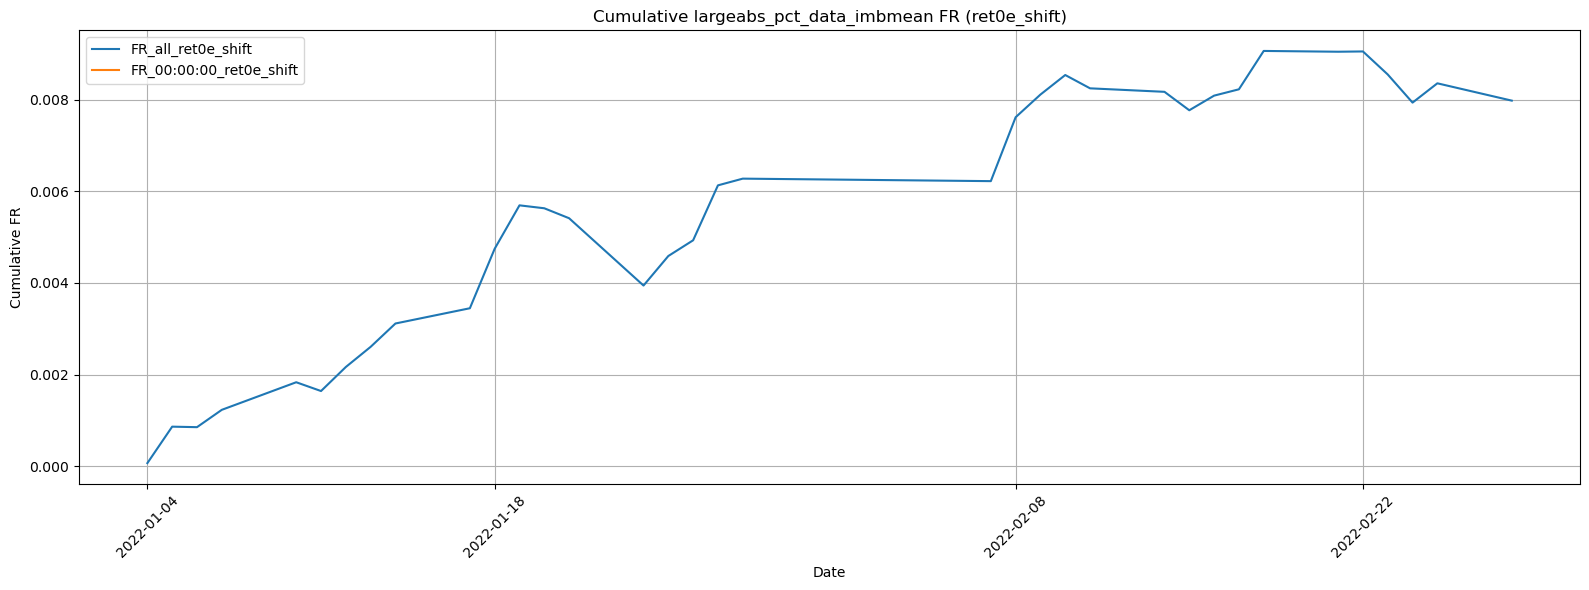

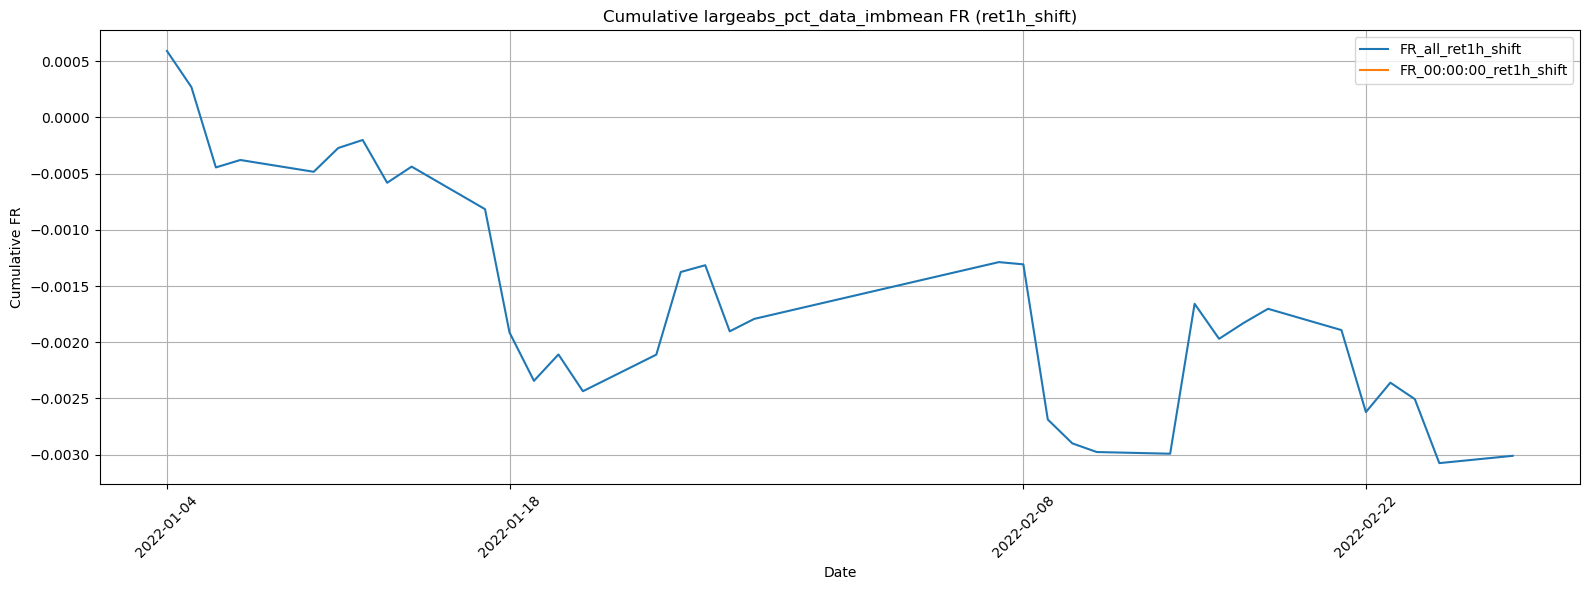

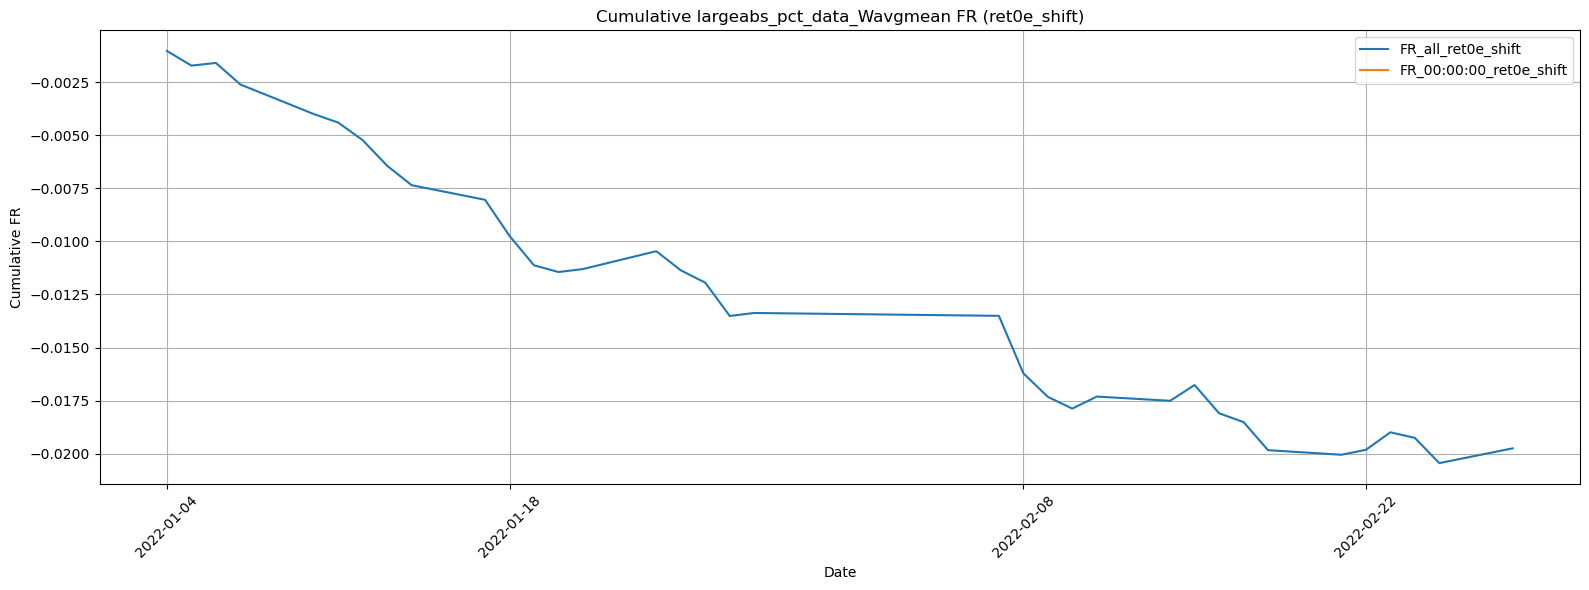

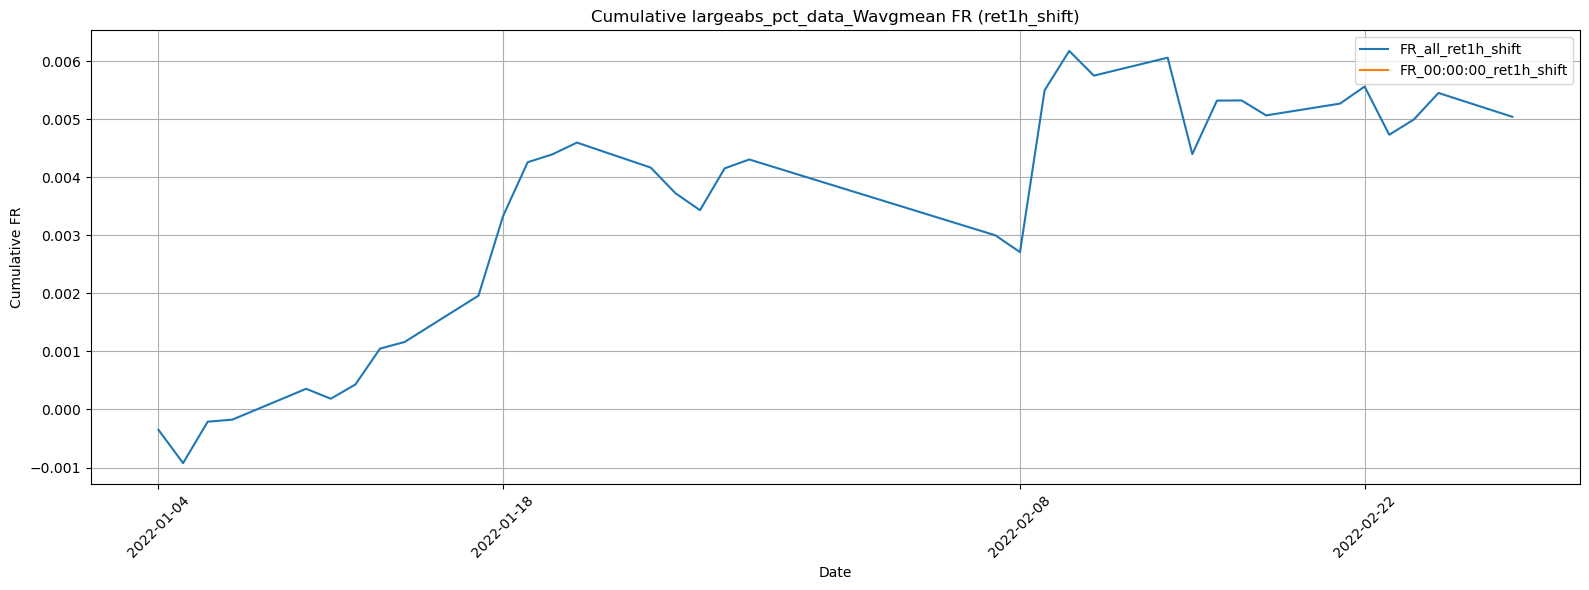

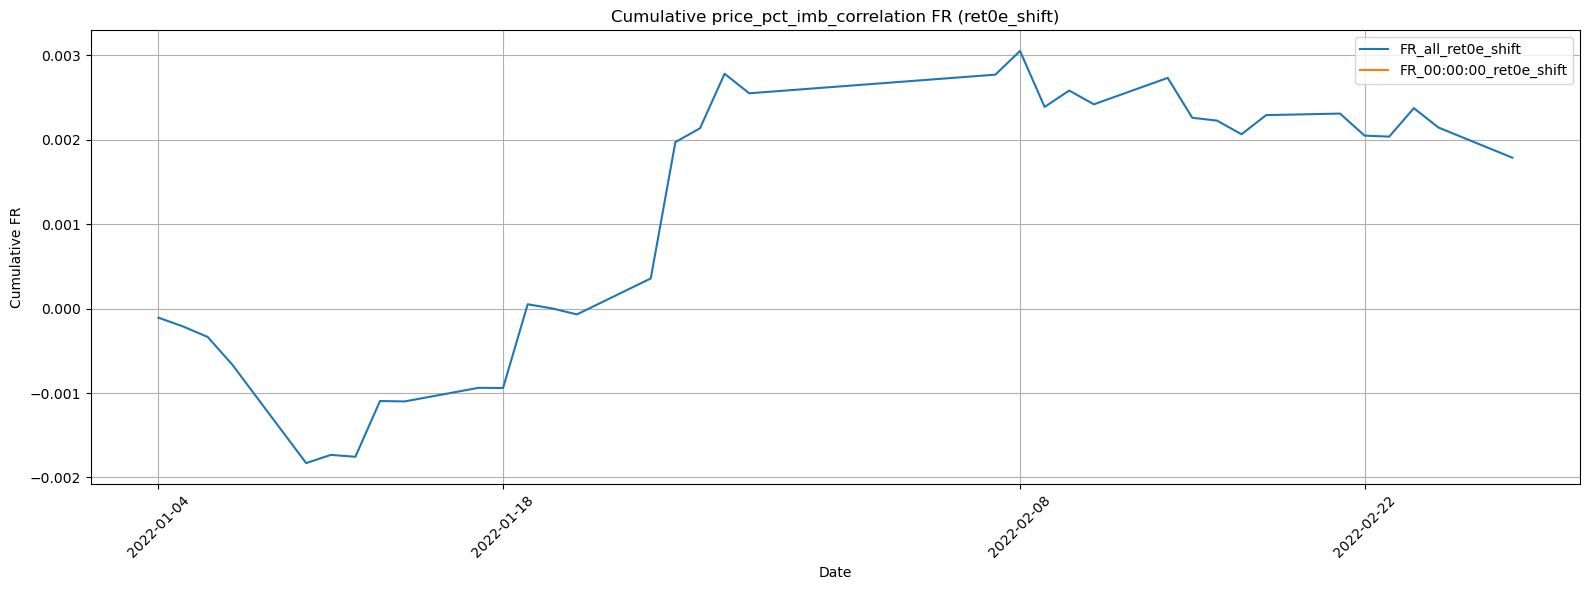

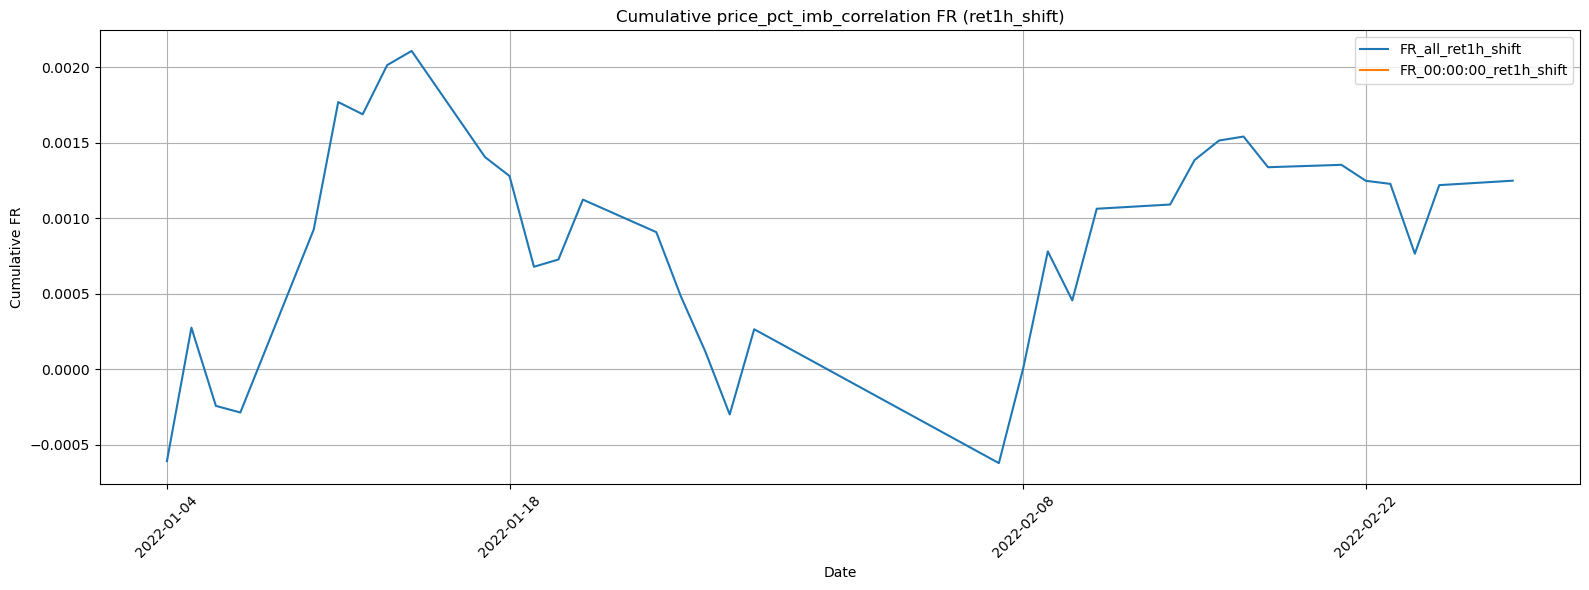

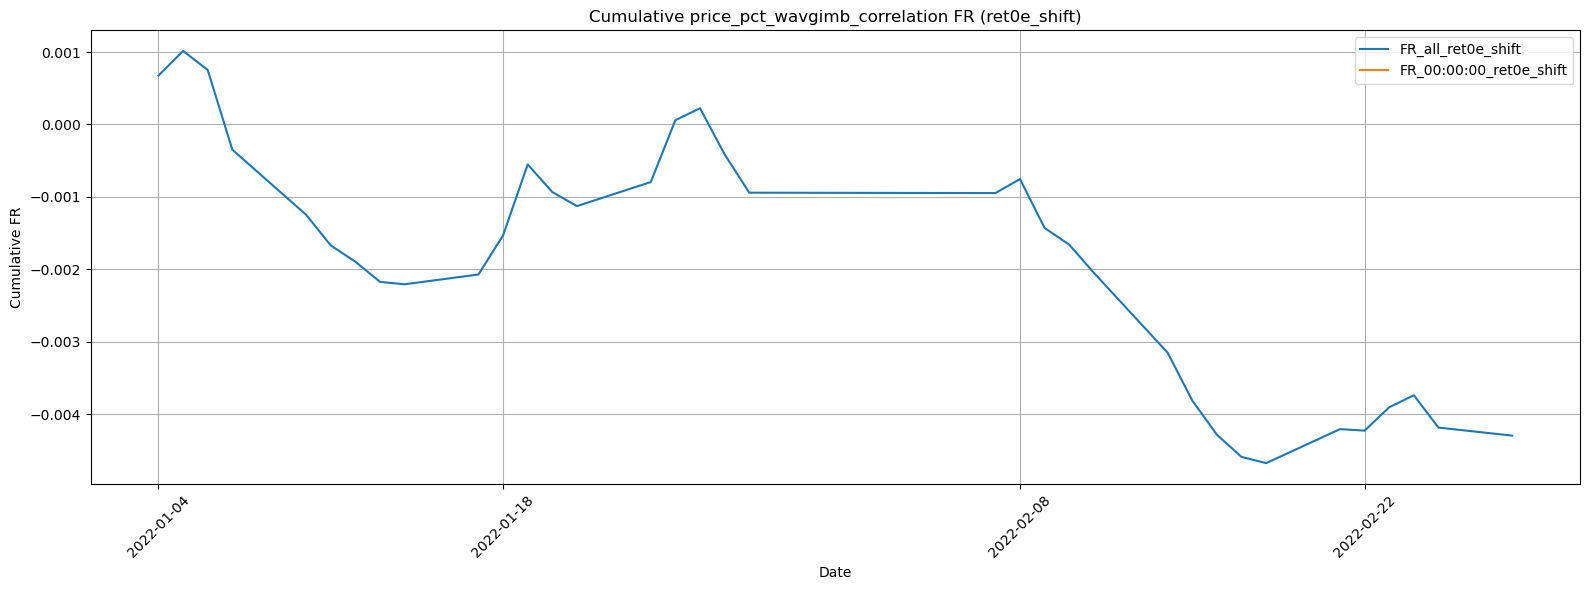

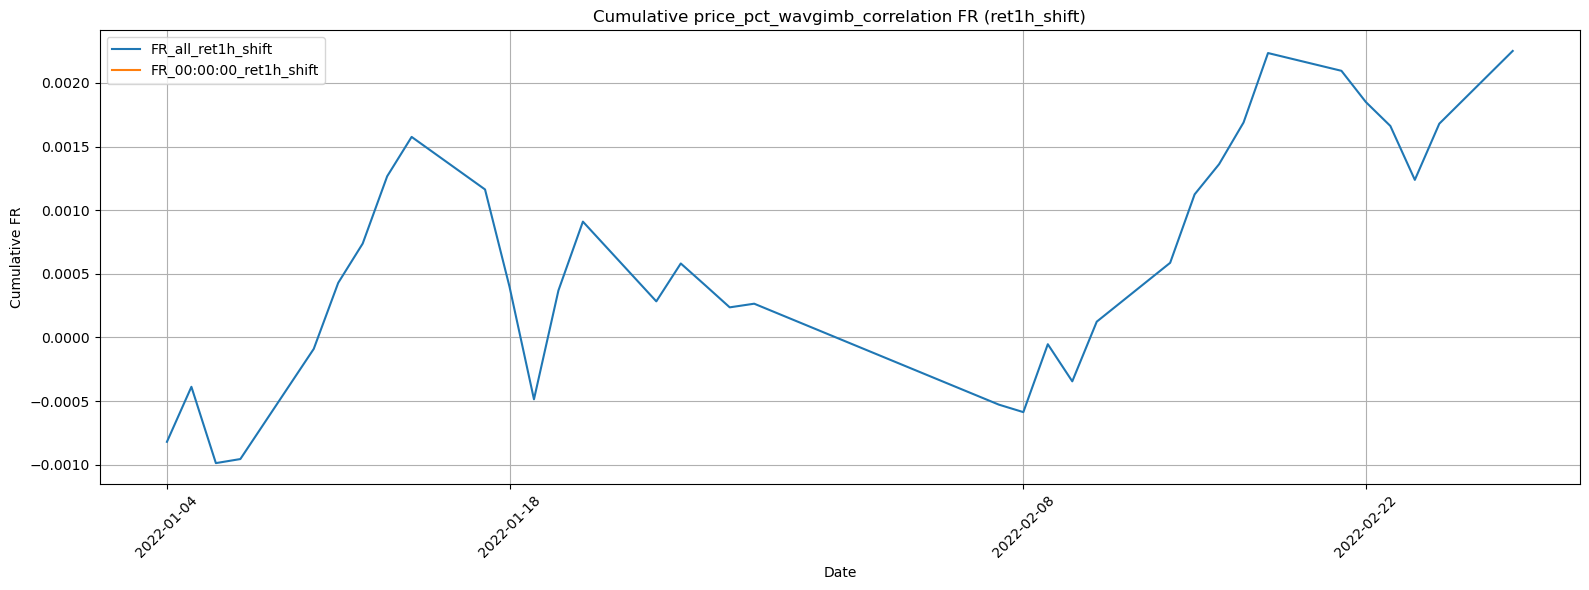

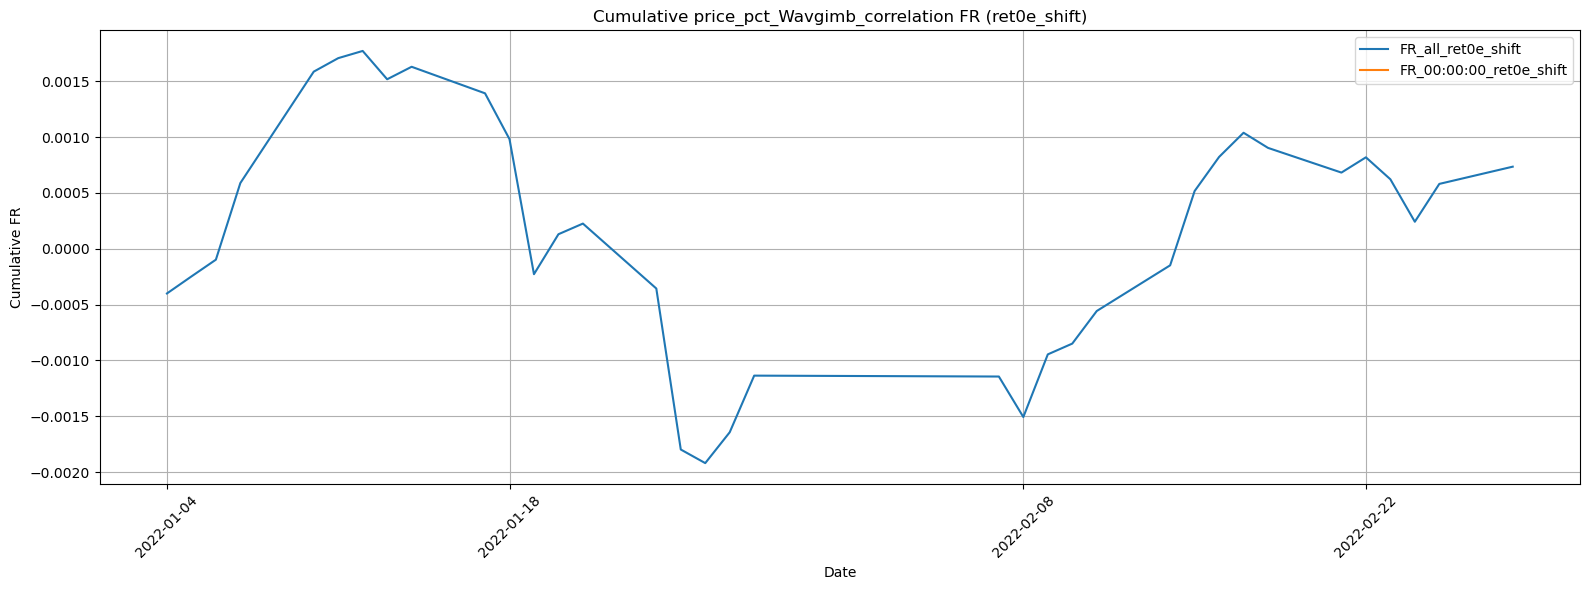

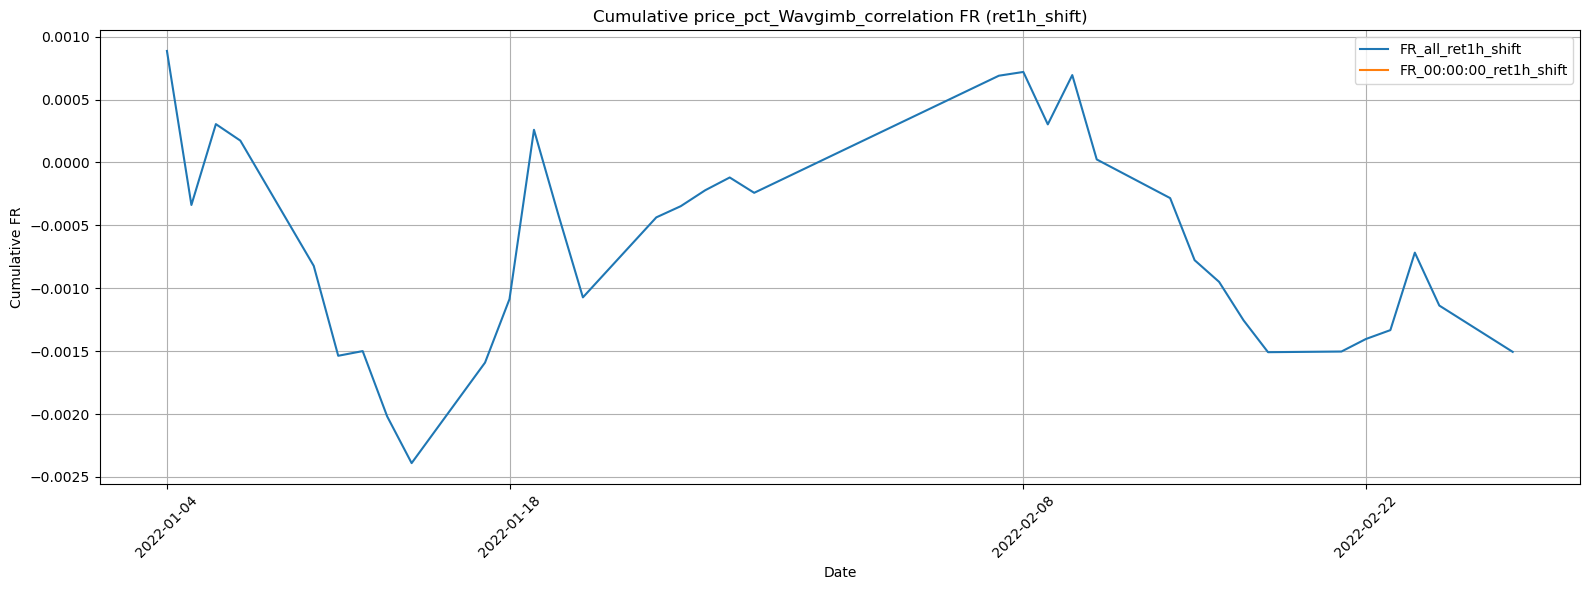

In [65]:
for col in  ['high_price_imb_mean', 'high_price_wavgimb_mean',
       'high_price_Wavgimb_mean', 'low_price_imb_mean',
       'low_price_wavgimb_mean', 'low_price_Wavgimb_mean', 'rising_imb_mean',
       'rising_wavgimb_mean', 'rising_Wavgimb_mean', 'falling_imb_mean',
       'falling_wavgimb_mean', 'falling_Wavgimb_mean', 'high_pct_imb_mean',
       'high_pct_wavgimb_mean', 'high_pct_Wavgimb_mean', 'low_pct_imb_mean',
       'low_pct_wavgimb_mean', 'low_pct_Wavgimb_mean',
       'largeabs_pct_data_imbmean', 'largeabs_pct_data_Wavgmean',
       'price_pct_imb_correlation', 'price_pct_wavgimb_correlation',
       'price_pct_Wavgimb_correlation']:
    fr_plot_(feature_1min_df, col, time_points=['00:00:00'])

### Check Performance

In [ ]:
fr_plot_(intra, 'imb')

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def fr_plot_(df, feat_col, ret_cols = ['ret0e_shift', 'ret1h_shift'], time_points=['10:00:00', '10:30:00', '13:30:00', '14:00:00']):
    # 假设你已经有以下变量


    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}

    for tp in time_points:
        df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
        for ret_col in ret_cols:
            grouped = df_tp.groupby('date')
            x = df_tp[feat_col]
            y = df_tp[ret_col]
            mean_x = grouped[feat_col].transform('mean')
            mean_y = grouped[ret_col].transform('mean')
            std_x = grouped[feat_col].transform('std')

            cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
            std_x_daily = std_x.groupby(df_tp['date']).first()

            fr = cov_xy / std_x_daily.replace(0, np.nan)
            fr_time_results[f'FR_{tp}_{ret_col}'] = fr

    # 合并所有结果
    fr_all_df = pd.DataFrame(fr_all_results)
    fr_time_df = pd.DataFrame(fr_time_results)
    fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

    # 计算 cumulative FR
    cumulative_fr_df = fr_df.cumsum()


    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'Cumulative {feat_col} FR (ret0e_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'Cumulative {feat_col} FR (ret1h_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
### NewOrderDynamic

In [ ]:
import pandas as pd
import numpy as np

def calculate_order_book_factors(intra_df):
    """
    计算订单簿的多个因子
    
    参数:
    intra_df: 包含订单簿数据的DataFrame
    
    返回:
    包含所有计算因子的DataFrame
    """
    # 确保数据按时间排序
    intra_df = intra_df.sort_values('datetime')
    
    # 复制原始数据，避免修改
    df = intra_df.copy()
    
    # 转换datetime列为datetime类型
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    # 初始化结果列
    df['price_range_volume'] = np.nan
    df['level1_change'] = np.nan
    df['level1_historical_change'] = np.nan
    df['up_trend_buyer'] = np.nan
    df['up_trend_seller'] = np.nan
    df['down_trend_buyer'] = np.nan
    df['down_trend_seller'] = np.nan
    df['max_volume_level'] = np.nan
    df['max_volume_price_pct'] = np.nan
    df['max_volume_level_change'] = np.nan
    df['seller_avg_volume'] = np.nan
    df['buyer_avg_volume'] = np.nan
    
    # 遍历每一行计算因子
    for i in range(len(df)):
        current_time = df.iloc[i]['datetime']
        current_order_book_id = df.iloc[i]['order_book_id']
        
        # 筛选过去5分钟的数据
        past_5min = df[
            (df['datetime'] >= current_time - pd.Timedelta(minutes=5)) & 
            (df['datetime'] <= current_time) &
            (df['order_book_id'] == current_order_book_id)
        ]
        
        # 筛选过去1分钟的数据
        past_1min = df[
            (df['datetime'] >= current_time - pd.Timedelta(minutes=1)) & 
            (df['datetime'] <= current_time) &
            (df['order_book_id'] == current_order_book_id)
        ]
        
        # 1. 计算过去5min，订单簿中间价扫过区间的价格上新增的量
        mid_price = (df.iloc[i]['a1'] + df.iloc[i]['b1']) / 2
        price_range = (past_5min['a1'].max() - past_5min['b1'].min())
        df.loc[i, 'price_range_volume'] = calculate_price_range_volume(past_5min, price_range)
        
        # 2. 当前1档位level变化量
        df.loc[i, 'level1_change'] = df.iloc[i]['a1_v'] - past_5min.iloc[0]['a1_v']
        
        # 3. 当前1档位，在过去5min在5档订单簿中同价量的变化
        df.loc[i, 'level1_historical_change'] = calculate_level1_historical_change(
            past_5min, df.iloc[i]['a1'], df.iloc[i]['b1']
        )
        
        # 4. 价格上涨时段的买卖方变化
        if i > 0 and df.iloc[i]['last'] > df.iloc[i-1]['last']:
            df.loc[i, 'up_trend_buyer'], df.loc[i, 'up_trend_seller'] = calculate_up_trend_changes(past_5min)
        
        # 5. 价格下跌时段的买卖方变化
        if i > 0 and df.iloc[i]['last'] < df.iloc[i-1]['last']:
            df.loc[i, 'down_trend_buyer'], df.loc[i, 'down_trend_seller'] = calculate_down_trend_changes(past_5min)
        
        # 6. 买卖方订单簿的最大量对应的level及其变化
        max_level, max_price = find_max_volume_level(past_5min)
        df.loc[i, 'max_volume_level'] = max_level
        
        if not past_1min.empty:
            pct_change = (max_price - past_1min.iloc[0][f"{'a' if max_level < 6 else 'b'}{max_level if max_level < 6 else max_level-5}"]) / past_1min.iloc[0][f"{'a' if max_level < 6 else 'b'}{max_level if max_level < 6 else max_level-5}"] * 100
            df.loc[i, 'max_volume_price_pct'] = pct_change
            
            level_change = calculate_max_level_change(past_1min, max_level, max_price)
            df.loc[i, 'max_volume_level_change'] = level_change
        
        # 7. 卖方订单簿因子
        seller_avg = calculate_seller_avg_volume(past_5min, df.iloc[i]['a1'])
        df.loc[i, 'seller_avg_volume'] = seller_avg if seller_avg is not None else np.nan
        
        # 8. 买方订单簿因子
        buyer_avg = calculate_buyer_avg_volume(past_5min, df.iloc[i]['b1'])
        df.loc[i, 'buyer_avg_volume'] = buyer_avg if buyer_avg is not None else np.nan
    
    return df

def calculate_price_range_volume(past_5min, price_range):
    """计算价格区间上的新增量"""
    # 获取最高卖价和最低买价
    max_ask = past_5min['a1'].max()
    min_bid = past_5min['b1'].min()
    
    # 计算价格区间内的新增量
    volume = 0
    for _, row in past_5min.iterrows():
        for level in range(1, 6):
            if min_bid <= row[f'a{level}'] <= max_ask:
                volume += row[f'a{level}_v']
            if min_bid <= row[f'b{level}'] <= max_ask:
                volume += row[f'b{level}_v']
    
    return volume

def calculate_level1_historical_change(past_5min, current_ask1, current_bid1):
    """计算当前1档位在过去5min在5档订单簿中同价量的变化"""
    if past_5min.empty:
        return 0
    
    # 初始化变化量
    ask_change = 0
    bid_change = 0
    
    # 获取最早时间点的数据
    earliest = past_5min.iloc[0]
    
    # 计算卖一价在历史订单簿中的变化
    for level in range(1, 6):
        if earliest[f'a{level}'] == current_ask1:
            ask_change = current_ask1 - earliest[f'a{level}']
            break
    
    # 计算买一价在历史订单簿中的变化
    for level in range(1, 6):
        if earliest[f'b{level}'] == current_bid1:
            bid_change = current_bid1 - earliest[f'b{level}']
            break
    
    return ask_change + bid_change

def calculate_up_trend_changes(past_5min):
    """计算价格上涨时段的买卖方变化"""
    if len(past_5min) < 2:
        return np.nan, np.nan
    
    # 筛选上涨时段的数据
    up_trend = pd.DataFrame(columns=past_5min.columns)
    for i in range(1, len(past_5min)):
        if past_5min.iloc[i]['last'] > past_5min.iloc[i-1]['last']:
            up_trend = pd.concat([up_trend, past_5min.iloc[[i]]])
    
    if up_trend.empty:
        return np.nan, np.nan
    
    # 计算买方变化
    buyer_decrease = 0
    buyer_appearance = 0
    
    # 计算卖方变化
    seller_decrease = 0
    seller_eaten = 0
    
    # 遍历上涨时段的数据
    for i in range(1, len(up_trend)):
        current = up_trend.iloc[i]
        previous = up_trend.iloc[i-1]
        
        # 买方变化计算
        for level in range(1, 5):  # 从1档位滑到5档位
            # 本level订单的减小量
            buyer_decrease += max(0, previous[f'b{level}_v'] - current[f'b{level}_v'])
            
            # 前方订单的出现量
            if level < 5:
                buyer_appearance += max(0, current[f'b{level+1}_v'] - previous[f'b{level+1}_v'])
        
        # 卖方变化计算
        for level in range(1, 5):  # 从高档位滑到1档位
            # 低档位订单被吃掉量
            if level < 5:
                seller_eaten += max(0, previous[f'a{level+1}_v'] - current[f'a{level+1}_v'])
            
            # 本档位订单的减小量
            seller_decrease += max(0, previous[f'a{level}_v'] - current[f'a{level}_v'])
    
    return buyer_decrease + buyer_appearance, seller_eaten + seller_decrease

def calculate_down_trend_changes(past_5min):
    """计算价格下跌时段的买卖方变化"""
    if len(past_5min) < 2:
        return np.nan, np.nan
    
    # 筛选下跌时段的数据
    down_trend = pd.DataFrame(columns=past_5min.columns)
    for i in range(1, len(past_5min)):
        if past_5min.iloc[i]['last'] < past_5min.iloc[i-1]['last']:
            down_trend = pd.concat([down_trend, past_5min.iloc[[i]]])
    
    if down_trend.empty:
        return np.nan, np.nan
    
    # 计算卖方变化
    seller_decrease = 0
    seller_appearance = 0
    
    # 计算买方变化
    buyer_decrease = 0
    buyer_eaten = 0
    
    # 遍历下跌时段的数据
    for i in range(1, len(down_trend)):
        current = down_trend.iloc[i]
        previous = down_trend.iloc[i-1]
        
        # 卖方变化计算
        for level in range(1, 5):  # 从1档位滑到5档位
            # 本level订单的减小量
            seller_decrease += max(0, previous[f'a{level}_v'] - current[f'a{level}_v'])
            
            # 前方订单的出现量
            if level < 5:
                seller_appearance += max(0, current[f'a{level+1}_v'] - previous[f'a{level+1}_v'])
        
        # 买方变化计算
        for level in range(1, 5):  # 从高档位滑到1档位
            # 低档位订单被吃掉量
            if level < 5:
                buyer_eaten += max(0, previous[f'b{level+1}_v'] - current[f'b{level+1}_v'])
            
            # 本档位订单的减小量
            buyer_decrease += max(0, previous[f'b{level}_v'] - current[f'b{level}_v'])
    
    return buyer_eaten + buyer_decrease, seller_decrease + seller_appearance

def find_max_volume_level(past_5min):
    """找到买卖方订单簿的最大量对应的level及其价格"""
    if past_5min.empty:
        return np.nan, np.nan
    
    # 获取最新时间点的数据
    latest = past_5min.iloc[-1]
    
    # 查找最大量对应的level
    max_volume = -1
    max_level = 0
    max_price = 0
    
    # 检查卖方订单簿
    for level in range(1, 6):
        if latest[f'a{level}_v'] > max_volume:
            max_volume = latest[f'a{level}_v']
            max_level = level
            max_price = latest[f'a{level}']
    
    # 检查买方订单簿
    for level in range(1, 6):
        if latest[f'b{level}_v'] > max_volume:
            max_volume = latest[f'b{level}_v']
            max_level = level + 5  # 买方level用6-10表示
            max_price = latest[f'b{level}']
    
    return max_level, max_price

def calculate_max_level_change(past_1min, max_level, max_price):
    """计算最大量对应价格在过去1min的level变化量"""
    if past_1min.empty:
        return np.nan
    
    # 获取最早和最新时间点的数据
    earliest = past_1min.iloc[0]
    latest = past_1min.iloc[-1]
    
    # 确定是买方还是卖方
    is_buyer = max_level > 5
    level = max_level - 5 if is_buyer else max_level
    
    # 查找最早时间点该价格所在的level
    earliest_level = 0
    for i in range(1, 6):
        if is_buyer:
            if earliest[f'b{i}'] == max_price:
                earliest_level = i
                break
        else:
            if earliest[f'a{i}'] == max_price:
                earliest_level = i
                break
    
    # 计算level变化量
    return level - earliest_level

def calculate_seller_avg_volume(past_5min, current_ask1):
    """计算卖方订单簿因子"""
    if past_5min.empty:
        return np.nan
    
    # 找到过去5分钟卖一价的最高值
    max_ask1 = past_5min['a1'].max()
    
    # 如果当前卖一价就是最高值，返回NaN
    if current_ask1 >= max_ask1:
        return np.nan
    
    # 找到最高卖一价的时刻t
    t_row = past_5min.loc[past_5min['a1'].idxmax()]
    
    # 筛选从t时刻到现在的数据
    t_time = t_row['datetime']
    relevant_data = past_5min[past_5min['datetime'] >= t_time]
    
    # 计算t时刻卖一价与当前时刻卖一价之间的挂单量的平均值
    avg_volume = 0
    count = 0
    
    for _, row in relevant_data.iterrows():
        for level in range(1, 6):
            # 检查价格是否在区间内
            if t_row['a1'] >= row[f'a{level}'] >= current_ask1:
                avg_volume += row[f'a{level}_v']
                count += 1
    
    return avg_volume / count if count > 0 else np.nan

def calculate_buyer_avg_volume(past_5min, current_bid1):
    """计算买方订单簿因子"""
    if past_5min.empty:
        return np.nan
    
    # 找到过去5分钟买一价的最低值
    min_bid1 = past_5min['b1'].min()
    
    # 如果当前买一价就是最低值，返回NaN
    if current_bid1 <= min_bid1:
        return np.nan
    
    # 找到最低买一价的时刻t
    t_row = past_5min.loc[past_5min['b1'].idxmin()]
    
    # 筛选从t时刻到现在的数据
    t_time = t_row['datetime']
    relevant_data = past_5min[past_5min['datetime'] >= t_time]
    
    # 计算t时刻买一价与当前时刻买一价之间的挂单量的平均值
    avg_volume = 0
    count = 0
    
    for _, row in relevant_data.iterrows():
        for level in range(1, 6):
            # 检查价格是否在区间内
            if t_row['b1'] <= row[f'b{level}'] <= current_bid1:
                avg_volume += row[f'b{level}_v']
                count += 1
    
    return avg_volume / count if count > 0 else np.nan

# 使用示例
# 假设intra_df是你的原始数据
# result_df = calculate_order_book_factors(intra_df)
# print(result_df[['datetime', 'price_range_volume', 'level1_change', ...]])  # 选择你需要的因子列